In [2]:
import copy

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
#!pip install seaborn #to directly install a library from a python script
import seaborn as sns


from sklearn.feature_selection import VarianceThreshold

from sklearn.preprocessing import MinMaxScaler

In [3]:
def load_data():
    #Either use numpy to get the csv as a numpy array
    #features_with_label_with_column_names = np.genfromtxt("../Data/newdata_hardness_as_target_csv_only_simulation_data.csv", delimiter=",")
    
    #Or use pandas to get a pandas data frame
    data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200+所有真实数据.xlsx')
    features_with_label_with_column_names =data.drop(columns=['数据来源'])
    return features_with_label_with_column_names

In [4]:
original_data = load_data()
#create a copy of the original data features and labels
copy_of_original_data = copy.deepcopy(original_data)

In [5]:
np.random.seed(42)
shuffled_data_indices = np.random.permutation(len(original_data))
test_split_size = 0.10
total_test_data = int(test_split_size * len(original_data))

#Since the data size is very small, we will use kFold crossvalidation, and thus do not need a separate validation set.

testing_indices = shuffled_data_indices[:total_test_data]
training_indices = shuffled_data_indices[total_test_data:]

print(f"The length of the original data set is: {len(original_data)}")
print(f"After the split, the training data and the testing data have lengths of: {len(training_indices)} and {len(testing_indices)}")

training_data = original_data.iloc[training_indices]
test_data = original_data.iloc[testing_indices]

The length of the original data set is: 897
After the split, the training data and the testing data have lengths of: 808 and 89


In [6]:
test_data

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
331,0.07,0.61,1.65,0.025,0.007,13.60,16.60,2.330,0.00,0.26,...,0.548098,0.199132,78.0,6.2,700,456.000,74.0,35.0,51.0,11817.9
638,0.14,0.25,0.55,0.010,0.009,0.18,2.44,1.030,0.00,0.13,...,0.000000,0.214617,17.0,6.7,500,457.000,294.0,20.0,47.0,2426.4
326,0.07,0.61,1.65,0.025,0.007,13.60,16.60,2.330,0.00,0.26,...,0.548098,0.199132,78.0,6.2,600,162.000,108.0,26.0,39.0,152758.0
847,0.06,0.54,1.67,0.028,0.016,12.62,17.71,0.020,0.00,0.05,...,0.548098,0.199132,73.0,5.8,650,150.000,177.0,12.0,16.0,129.9
39,0.10,0.38,0.40,0.015,0.001,0.12,8.53,0.960,0.00,0.00,...,0.000000,0.203545,16.0,10.1,650,177.000,50.0,11.4,14.7,59498.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,0.11,0.62,0.44,0.026,0.006,0.07,8.58,0.950,0.00,0.05,...,0.000000,0.278135,83.0,7.1,600,128.000,61.0,39.0,94.0,10758.4
495,0.06,0.59,1.69,0.024,0.017,13.32,16.73,2.380,0.00,0.07,...,0.548098,0.199132,74.0,5.0,600,129.000,127.0,33.0,43.0,62873.3
215,0.11,0.27,0.59,0.015,0.002,0.33,12.10,0.340,1.82,0.82,...,0.000000,0.258804,20.0,9.2,550,409.000,199.0,14.0,43.0,84914.3
734,0.07,0.18,0.24,0.009,0.002,0.00,2.58,0.027,1.60,0.00,...,0.000000,0.231682,88.0,5.9,575,278.625,140.0,31.0,85.0,1932.2


In [7]:
original_data.head()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,441.0,12.0,66.0,3121.7
1,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,373.0,9.0,48.0,15312.9
2,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,412.0,11.0,65.0,9154.2
3,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,550,496.0,245.0,7.0,33.0,13627.3
4,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,550,496.0,294.0,5.0,22.0,5300.3


In [8]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 897 entries, 0 to 896
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   C                            897 non-null    float64
 1   Si                           897 non-null    float64
 2   Mn                           897 non-null    float64
 3   P                            897 non-null    float64
 4   S                            897 non-null    float64
 5   Ni                           897 non-null    float64
 6   Cr                           897 non-null    float64
 7   Mo                           897 non-null    float64
 8   W                            897 non-null    float64
 9   Cu                           897 non-null    float64
 10  B                            897 non-null    float64
 11  Al                           897 non-null    float64
 12  Ti                           897 non-null    float64
 13  N                   

In [9]:
original_data.describe()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
count,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,...,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000
mean,0.092466,0.388417,0.968127,0.019344,0.005659,5.826382,12.485385,0.554208,0.436700,0.333759,...,0.087378,0.228200,59.155407,6.973133,630.852843,211.938127,131.591304,25.150613,46.324080,28289.387960
std,0.028382,0.161263,0.545320,0.006872,0.005287,6.106611,6.515219,0.640009,0.753284,0.711015,...,0.200753,0.066145,29.668355,1.783456,77.752846,95.983363,85.979901,16.025126,29.569239,36702.823214
min,0.060000,0.100000,0.240000,0.005000,0.001000,0.000000,0.920000,0.000000,0.000000,0.000000,...,0.000000,0.000000,14.000000,3.800000,450.000000,69.000000,14.000000,0.600000,0.000000,4.300000
25%,0.070000,0.250000,0.490000,0.015000,0.001000,0.120000,8.530000,0.040000,0.000000,0.000000,...,0.000000,0.203545,20.000000,5.800000,600.000000,150.000000,61.000000,13.000000,19.000000,1505.100000
50%,0.090000,0.380000,0.600000,0.020000,0.004000,0.360000,12.100000,0.420000,0.000000,0.062000,...,0.000000,0.258804,78.000000,6.200000,650.000000,169.000000,110.000000,22.000000,43.000000,11985.200000
75%,0.110000,0.540000,1.570000,0.025000,0.007000,11.320000,18.200000,0.890000,0.940000,0.170000,...,0.000000,0.258804,82.000000,8.900000,700.000000,255.000000,180.000000,32.000000,76.000000,42270.400000
max,0.210000,0.660000,1.710000,0.030000,0.017000,19.840000,24.600000,2.380000,1.870000,2.920000,...,0.548098,0.278135,88.000000,10.100000,800.000000,574.000000,510.000000,108.000000,97.000000,222705.300000


In [10]:
num_features = len(training_data.iloc[0]) - 1 # subtracting one because the data still contains the label column

raw_training_features, raw_training_labels = training_data.iloc[:,0:num_features], training_data.iloc[:,num_features]
raw_testing_features, raw_testing_labels = test_data.iloc[:,0:num_features], test_data.iloc[:,num_features]

#since the labels consist of a single column, pandas creates raw_labels variable as a pandas series, convert into df
raw_training_labels = pd.DataFrame(raw_training_labels)
raw_testing_labels = pd.DataFrame(raw_testing_labels)

In [11]:
features_description = raw_training_features.describe()
transposed_description = features_description.T
#add a new column that shows what percent of the samples are missing each features
transposed_description["missing_percent"] = 1 - (transposed_description["count"]/len(raw_training_features))

transposed_description["missing_percent"]

C                              0.0
Si                             0.0
Mn                             0.0
P                              0.0
S                              0.0
Ni                             0.0
Cr                             0.0
Mo                             0.0
W                              0.0
Cu                             0.0
B                              0.0
Al                             0.0
Ti                             0.0
N                              0.0
V                              0.0
Nb                             0.0
Zr                             0.0
Nb+Ta                          0.0
Co                             0.0
Sn                             0.0
ρ(g/㎤)                         0.0
R(Å)                           0.0
∆R                             0.0
χ                              0.0
∆χ                             0.0
VEC                            0.0
∆VEC                           0.0
dA                             0.0
dB                  

In [12]:
print(f"Shape of features before removing zero-variance features: {raw_training_features.shape}")
columns_before_removing_zero_variance_features = raw_training_features.columns

raw_training_features_with_high_variance = raw_training_features.loc[:, raw_training_features.std(axis=0) > 0.]

print(f"Shape of features after removing zero-variance features: {raw_training_features_with_high_variance.shape}")
columns_after_removing_zero_variance_features = raw_training_features_with_high_variance.columns

Shape of features before removing zero-variance features: (808, 56)
Shape of features after removing zero-variance features: (808, 56)


In [13]:
corr_matrix = raw_training_features_with_high_variance.corr()
min_variables_to_keep = 1
count_of_features = len(corr_matrix)

print("Performing Multicollinearity Analysis.")

#if current number if features > min number of features to keep
if count_of_features > min_variables_to_keep:
    
    while True:
        
        col_names = corr_matrix.keys() #get column names if present, else the column number
        eigen_vals, eigen_vects = np.linalg.eig(corr_matrix)
        #Note that numpy returns complex eigen values due to truncation and rounding-off
        
        #The condition indices are computed by finding the square root of the maximum eigenvalue divided by
        #the eigenvalues of the design matrix. 
        
        condition_indices = (max(eigen_vals)/eigen_vals)**(1/2)  #Taking the square-root to calculate
        
        #If the condition index <= 30, then multicollinearity is not severe.
        if max(condition_indices) <= 30 or count_of_features <= min_variables_to_keep:
            break
        
        for idx, val in enumerate(eigen_vals):
            if val == min(eigen_vals):
                
                for idxxx, eigen_vec in enumerate(eigen_vects[:,idx]):
                    
                    if abs(eigen_vec) == max( (abs(eigen_vects[:,idx]) )):
                        
                        mask = np.ones(len(corr_matrix), dtype = bool)
                        
                        for num, column in enumerate(corr_matrix.keys()):
                            mask[num] = num != idxxx
                            
                            if num == idxxx:
                                mask[num] = 0
                            else:
                                mask[num] = 1
                        
                        #Delete the row corresponding to this feature with the highest loading in the Eigen vector
                        corr_matrix = corr_matrix[mask]
                        #Delete the column corresponding to the feature that has the highest loading in the Eigen vector
                        corr_matrix.pop(col_names[idxxx])
                        
        
print("Number of features that will remain after removing multicollinearity: ", len(corr_matrix))


Performing Multicollinearity Analysis.
Number of features that will remain after removing multicollinearity:  25


C:\Users\zangd\AppData\Local\Temp\ipykernel_121208\3290063924.py:19: RuntimeWarning: invalid value encountered in sqrt
  condition_indices = (max(eigen_vals)/eigen_vals)**(1/2)  #Taking the square-root to calculate


In [14]:
features_after_multicollinearity_removal = corr_matrix.columns
features_after_multicollinearity_removal

Index(['Si', 'P', 'S', 'Mo', 'Cu', 'B', 'Ti', 'N', 'Nb+Ta', 'Sn', 'VEC', 'dA',
       'dC', 'cold', 'drwan', 'furancy', 'rotary', 'si',
       'Rockwell hardness(HRC)', 'Austenite grain size number',
       'Test Temparature(℃)', '0.2% Proof Stress(MPa)', 'Test stress(MPa)',
       'Elongation(%)', 'Reduction of Area(%)'],
      dtype='object')

In [15]:
features_without_multicollinearity = raw_training_features_with_high_variance[features_after_multicollinearity_removal]

features_without_multicollinearity.head()

,Si,P,S,Mo,Cu,B,Ti,N,Nb+Ta,Sn,...,furancy,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
280,0.24,0.030,0.001,0.480,2.92,0.0000,0.00,0.102,0.00,0.0,...,0.265966,0.000000,0.258804,84.0,8.9,625,180.0,260.0,24.0,41.0
165,0.18,0.009,0.002,0.027,0.00,0.0034,0.00,0.006,0.00,0.0,...,0.238093,0.000000,0.231682,88.0,5.9,550,318.0,160.0,37.0,86.0
611,0.54,0.028,0.016,0.020,0.05,0.0002,0.53,0.013,0.01,0.0,...,0.204643,0.548098,0.199132,73.0,5.8,700,146.0,61.0,7.0,7.0
772,0.27,0.015,0.002,0.340,0.82,0.0030,0.00,0.066,0.00,0.0,...,0.265966,0.000000,0.258804,20.0,9.2,600,332.0,190.0,25.0,73.0
380,0.40,0.026,0.001,0.000,0.00,0.0000,0.00,0.000,0.00,0.0,...,0.265966,0.000000,0.258804,82.0,8.9,650,169.0,160.0,20.0,22.0


In [16]:
features_to_scale = features_without_multicollinearity[features_without_multicollinearity.columns[~features_without_multicollinearity.columns.isin(["% of Co","%Fe"])]]
features_to_scale.head()

,Si,P,S,Mo,Cu,B,Ti,N,Nb+Ta,Sn,...,furancy,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
280,0.24,0.030,0.001,0.480,2.92,0.0000,0.00,0.102,0.00,0.0,...,0.265966,0.000000,0.258804,84.0,8.9,625,180.0,260.0,24.0,41.0
165,0.18,0.009,0.002,0.027,0.00,0.0034,0.00,0.006,0.00,0.0,...,0.238093,0.000000,0.231682,88.0,5.9,550,318.0,160.0,37.0,86.0
611,0.54,0.028,0.016,0.020,0.05,0.0002,0.53,0.013,0.01,0.0,...,0.204643,0.548098,0.199132,73.0,5.8,700,146.0,61.0,7.0,7.0
772,0.27,0.015,0.002,0.340,0.82,0.0030,0.00,0.066,0.00,0.0,...,0.265966,0.000000,0.258804,20.0,9.2,600,332.0,190.0,25.0,73.0
380,0.40,0.026,0.001,0.000,0.00,0.0000,0.00,0.000,0.00,0.0,...,0.265966,0.000000,0.258804,82.0,8.9,650,169.0,160.0,20.0,22.0


In [17]:
features_to_scale.min(axis = 0)

Si                               0.100000
P                                0.005000
S                                0.001000
Mo                               0.000000
Cu                               0.000000
B                                0.000000
Ti                               0.000000
N                                0.000000
Nb+Ta                            0.000000
Sn                               0.000000
VEC                              5.814097
dA                               0.000000
dC                               0.010000
cold                             0.000000
drwan                            0.000000
furancy                          0.000000
rotary                           0.000000
si                               0.000000
Rockwell hardness(HRC)          14.000000
Austenite grain size number      3.800000
Test Temparature(℃)            450.000000
0.2% Proof Stress(MPa)          69.000000
Test stress(MPa)                14.000000
Elongation(%)                    0

In [18]:
features_to_scale.max(axis = 0)

Si                               0.660000
P                                0.030000
S                                0.017000
Mo                               2.380000
Cu                               2.920000
B                                0.003400
Ti                               0.530000
N                                0.272000
Nb+Ta                            0.740000
Sn                               0.027000
VEC                              7.682335
dA                               0.210000
dC                               0.250000
cold                             0.309931
drwan                            0.665160
furancy                          0.285832
rotary                           0.548098
si                               0.278135
Rockwell hardness(HRC)          88.000000
Austenite grain size number     10.100000
Test Temparature(℃)            800.000000
0.2% Proof Stress(MPa)         574.000000
Test stress(MPa)               510.000000
Elongation(%)                  108

In [19]:
minmax_scaler = MinMaxScaler()

#save the column names for later use
cols_in_final_features = features_to_scale.columns

normalized_training_features = pd.DataFrame(minmax_scaler.fit_transform(features_to_scale))

#assign the column names to the normalized data
normalized_training_features.columns = cols_in_final_features

print(f" feature mins : {minmax_scaler.data_min_}, \nfeature maxs: {minmax_scaler.data_max_}")


 feature mins : [1.00000000e-01 5.00000000e-03 1.00000000e-03 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 5.81409665e+00 0.00000000e+00
 1.00000000e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.40000000e+01 3.80000000e+00
 4.50000000e+02 6.90000000e+01 1.40000000e+01 6.00000000e-01
 0.00000000e+00], 
feature maxs: [6.60000000e-01 3.00000000e-02 1.70000000e-02 2.38000000e+00
 2.92000000e+00 3.40000000e-03 5.30000000e-01 2.72000000e-01
 7.40000000e-01 2.70000000e-02 7.68233463e+00 2.10000000e-01
 2.50000000e-01 3.09930644e-01 6.65159969e-01 2.85832428e-01
 5.48098174e-01 2.78135379e-01 8.80000000e+01 1.01000000e+01
 8.00000000e+02 5.74000000e+02 5.10000000e+02 1.08000000e+02
 9.70000000e+01]


In [20]:
normalized_training_features.describe()

,Si,P,S,Mo,Cu,B,Ti,N,Nb+Ta,Sn,...,furancy,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
count,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,...,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000
mean,0.508000,0.566980,0.289658,0.232486,0.112259,0.243120,0.092439,0.145396,0.050901,0.018564,...,0.803373,0.148515,0.820034,0.602877,0.508035,0.514763,0.282950,0.238114,0.231405,0.483878
std,0.286250,0.275285,0.329545,0.265601,0.240415,0.329834,0.255654,0.179628,0.211131,0.135064,...,0.272374,0.355830,0.240417,0.403498,0.284436,0.220043,0.190522,0.173812,0.149318,0.305272
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.267857,0.400000,0.000000,0.016807,0.000000,0.000000,0.000000,0.036765,0.000000,0.000000,...,0.731819,0.000000,0.731819,0.081081,0.317460,0.428571,0.160396,0.094758,0.124767,0.195876
50%,0.500000,0.600000,0.187500,0.176471,0.017123,0.000000,0.000000,0.104412,0.000000,0.000000,...,0.930495,0.000000,0.930495,0.864865,0.380952,0.571429,0.198020,0.193548,0.202048,0.458763
75%,0.785714,0.800000,0.500000,0.373950,0.058219,0.529412,0.020755,0.209559,0.001351,0.000000,...,0.930495,0.000000,0.930495,0.918919,0.809524,0.714286,0.358416,0.334677,0.301676,0.793814
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
#Store the name of the label name before passing through the scaler.
label_column_name = raw_training_labels.columns

target_scaler = MinMaxScaler()
normalized_training_labels = pd.DataFrame(target_scaler.fit_transform(raw_training_labels))

#reassign the name to the label
normalized_training_labels.columns = label_column_name

print(f"The maximum and minimum targets of the training data are {target_scaler.data_max_} and {target_scaler.data_min_}")

The maximum and minimum targets of the training data are [222705.3] and [4.3]


In [22]:
normalized_training_features.head()

,Si,P,S,Mo,Cu,B,Ti,N,Nb+Ta,Sn,...,furancy,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
0,0.250000,1.00,0.0000,0.201681,1.000000,0.000000,0.0,0.375000,0.000000,0.0,...,0.930495,0.0,0.930495,0.945946,0.809524,0.500000,0.219802,0.495968,0.217877,0.422680
1,0.142857,0.16,0.0625,0.011345,0.000000,1.000000,0.0,0.022059,0.000000,0.0,...,0.832981,0.0,0.832981,1.000000,0.333333,0.285714,0.493069,0.294355,0.338920,0.886598
2,0.785714,0.92,0.9375,0.008403,0.017123,0.058824,1.0,0.047794,0.013514,0.0,...,0.715954,1.0,0.715954,0.797297,0.317460,0.714286,0.152475,0.094758,0.059590,0.072165
3,0.303571,0.40,0.0625,0.142857,0.280822,0.882353,0.0,0.242647,0.000000,0.0,...,0.930495,0.0,0.930495,0.081081,0.857143,0.428571,0.520792,0.354839,0.227188,0.752577
4,0.535714,0.84,0.0000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.930495,0.0,0.930495,0.918919,0.809524,0.571429,0.198020,0.294355,0.180633,0.226804


In [23]:
normalized_training_labels.head()

,Time to Rupture(h)
0,0.018589
1,0.013079
2,0.096295
3,0.005117
4,0.043168


In [24]:
normalized_training_features_and_targets = pd.concat([normalized_training_features,normalized_training_labels], axis =1)
normalized_training_features_and_targets.head()

,Si,P,S,Mo,Cu,B,Ti,N,Nb+Ta,Sn,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.250000,1.00,0.0000,0.201681,1.000000,0.000000,0.0,0.375000,0.000000,0.0,...,0.0,0.930495,0.945946,0.809524,0.500000,0.219802,0.495968,0.217877,0.422680,0.018589
1,0.142857,0.16,0.0625,0.011345,0.000000,1.000000,0.0,0.022059,0.000000,0.0,...,0.0,0.832981,1.000000,0.333333,0.285714,0.493069,0.294355,0.338920,0.886598,0.013079
2,0.785714,0.92,0.9375,0.008403,0.017123,0.058824,1.0,0.047794,0.013514,0.0,...,1.0,0.715954,0.797297,0.317460,0.714286,0.152475,0.094758,0.059590,0.072165,0.096295
3,0.303571,0.40,0.0625,0.142857,0.280822,0.882353,0.0,0.242647,0.000000,0.0,...,0.0,0.930495,0.081081,0.857143,0.428571,0.520792,0.354839,0.227188,0.752577,0.005117
4,0.535714,0.84,0.0000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.930495,0.918919,0.809524,0.571429,0.198020,0.294355,0.180633,0.226804,0.043168


In [38]:
normalized_training_features_and_targets.to_excel(r'D:\creep rupture\TR+TS\GAN200+所有真实数据train.xlsx', index = False, header = True)

In [26]:
raw_testing_features.head()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rolling,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
331,0.07,0.61,1.65,0.025,0.007,13.60,16.60,2.33,0.0,0.26,...,0.0,0.548098,0.199132,78.0,6.2,700,456.0,74.0,35.0,51.0
638,0.14,0.25,0.55,0.010,0.009,0.18,2.44,1.03,0.0,0.13,...,0.0,0.000000,0.214617,17.0,6.7,500,457.0,294.0,20.0,47.0
326,0.07,0.61,1.65,0.025,0.007,13.60,16.60,2.33,0.0,0.26,...,0.0,0.548098,0.199132,78.0,6.2,600,162.0,108.0,26.0,39.0
847,0.06,0.54,1.67,0.028,0.016,12.62,17.71,0.02,0.0,0.05,...,0.0,0.548098,0.199132,73.0,5.8,650,150.0,177.0,12.0,16.0
39,0.10,0.38,0.40,0.015,0.001,0.12,8.53,0.96,0.0,0.00,...,0.0,0.000000,0.203545,16.0,10.1,650,177.0,50.0,11.4,14.7


In [27]:
raw_testing_features = raw_testing_features[features_after_multicollinearity_removal]

In [28]:
raw_testing_labels

,Time to Rupture(h)
331,11817.9
638,2426.4
326,152758.0
847,129.9
39,59498.1
...,...
174,10758.4
495,62873.3
215,84914.3
734,1932.2


In [29]:
scaled_testing_features = pd.DataFrame(minmax_scaler.transform(raw_testing_features))

In [30]:
minmax_scaler.data_min_

array([1.00000000e-01, 5.00000000e-03, 1.00000000e-03, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 5.81409665e+00, 0.00000000e+00,
       1.00000000e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.40000000e+01, 3.80000000e+00,
       4.50000000e+02, 6.90000000e+01, 1.40000000e+01, 6.00000000e-01,
       0.00000000e+00])

In [31]:
minmax_scaler.data_max_

array([6.60000000e-01, 3.00000000e-02, 1.70000000e-02, 2.38000000e+00,
       2.92000000e+00, 3.40000000e-03, 5.30000000e-01, 2.72000000e-01,
       7.40000000e-01, 2.70000000e-02, 7.68233463e+00, 2.10000000e-01,
       2.50000000e-01, 3.09930644e-01, 6.65159969e-01, 2.85832428e-01,
       5.48098174e-01, 2.78135379e-01, 8.80000000e+01, 1.01000000e+01,
       8.00000000e+02, 5.74000000e+02, 5.10000000e+02, 1.08000000e+02,
       9.70000000e+01])

In [32]:
scaled_testing_features.columns = cols_in_final_features

In [33]:
scaled_testing_labels = pd.DataFrame(target_scaler.transform(raw_testing_labels))

In [34]:
target_scaler.data_min_

array([4.3])

In [35]:
target_scaler.data_max_

array([222705.3])

In [36]:
scaled_testing_labels.columns = label_column_name

scaled_testing_labels#.head()

,Time to Rupture(h)
0,0.053047
1,0.010876
2,0.685914
3,0.000564
4,0.267147
...,...
84,0.048289
85,0.282302
86,0.381274
87,0.008657


In [37]:
normalized_testing_features_and_targets = pd.concat([scaled_testing_features,scaled_testing_labels], axis =1)
normalized_testing_features_and_targets.head()

,Si,P,S,Mo,Cu,B,Ti,N,Nb+Ta,Sn,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.910714,0.80,0.3750,0.978992,0.089041,0.323529,0.081132,0.091912,0.013514,0.0,...,1.0,0.715954,0.864865,0.380952,0.714286,0.766337,0.120968,0.320298,0.525773,0.053047
1,0.267857,0.20,0.5000,0.432773,0.044521,0.000000,0.000000,0.037500,0.000000,0.0,...,0.0,0.771626,0.040541,0.460317,0.142857,0.768317,0.564516,0.180633,0.484536,0.010876
2,0.910714,0.80,0.3750,0.978992,0.089041,0.323529,0.081132,0.091912,0.013514,0.0,...,1.0,0.715954,0.864865,0.380952,0.428571,0.184158,0.189516,0.236499,0.402062,0.685914
3,0.785714,0.92,0.9375,0.008403,0.017123,0.058824,1.000000,0.047794,0.013514,0.0,...,1.0,0.715954,0.797297,0.317460,0.571429,0.160396,0.328629,0.106145,0.164948,0.000564
4,0.500000,0.40,0.0000,0.403361,0.000000,0.000000,0.018868,0.183824,0.000000,0.0,...,0.0,0.731819,0.027027,1.000000,0.571429,0.213861,0.072581,0.100559,0.151546,0.267147


In [39]:
normalized_testing_features_and_targets.to_excel()

## 特征重要性

In [40]:
data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200+所有真实数据train.xlsx')

In [41]:
data.columns

Index(['Si', 'P', 'S', 'Mo', 'Cu', 'B', 'Ti', 'N', 'Nb+Ta', 'Sn', 'VEC', 'dA',
       'dC', 'cold', 'drwan', 'furancy', 'rotary', 'si',
       'Rockwell hardness(HRC)', 'Austenite grain size number',
       'Test Temparature(℃)', '0.2% Proof Stress(MPa)', 'Test stress(MPa)',
       'Elongation(%)', 'Reduction of Area(%)', 'Time to Rupture(h)'],
      dtype='object')

In [42]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
X = data.drop(columns=['Time to Rupture(h)'])
y = data['Time to Rupture(h)']

estimator = RFR()

print("递归特征消除法和曲线图选取最优特征数量")

score = []
for i in range(1, 10, 1):
    selector = RFE(estimator, n_features_to_select=i, step=1)
    selector = selector.fit(X, y)
    print(selector.support_)
    print(selector.ranking_)
    print(selector.n_features_)
    once = cross_val_score(estimator, selector.transform(X), y, cv=10).mean()
    score.append(once)

print(max(score), (score.index(max(score)) * 1) + 1)
print(score)

递归特征消除法和曲线图选取最优特征数量
[False False False False False False False False False False False False
 False False False False False False False False False False False  True
 False]
[10 14 15 11 12 22 16  6  8 25  3 18 19 21 23 20 24 17  9 13  5  7  2  1
  4]
1
[False False False False False False False False False False False False
 False False False False False False False False False False False  True
  True]
[10 13 17  8 11 20 15  3  7 24  5 14 18 16 22 19 23 21  9 12  4  6  2  1
  1]
2
[False False False False False False False False False False False False
 False False False False False False False False False False  True  True
  True]
[ 9 11 14  8 10 17 13  2  6 23  5 16 20 15 21 18 22 19  7 12  3  4  1  1
  1]
3
[False False False False False False False False False False  True False
 False False False False False False False False False False  True  True
  True]
[ 8 12 15  7  9 16 13  3  5 22  1 14 17 19 20 11 21 18  6 10  2  4  1  1
  1]
4
[False False False False False False False F

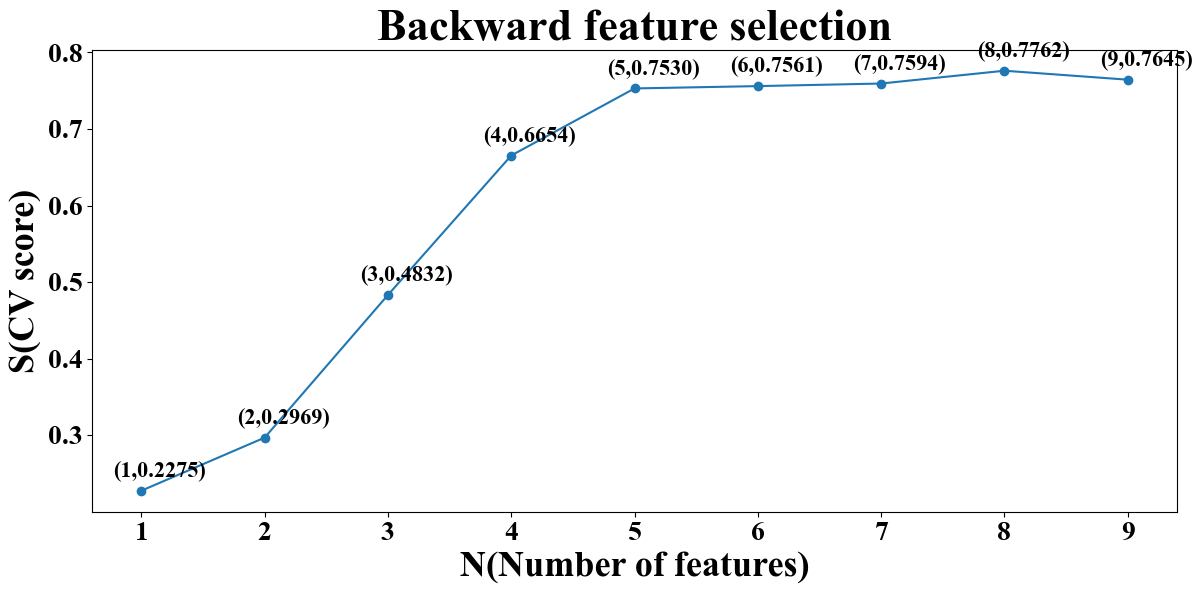

In [43]:
plt.figure(figsize=[14, 6])
plt.plot(range(1, 10, 1), score, marker='o')
plt.xlabel('N(Number of features)',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':26
       })
plt.ylabel('S(CV score)',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':26
       })
for xy in zip(range(1, 10, 1), score):
    plt.annotate("(%s,%.4f)" % xy, xy=xy, xytext=(-20, 10),textcoords='offset points',weight='bold',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':16
       })
plt.title('Backward feature selection',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':32
       })
plt.xticks(fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':20
       })
plt.yticks(fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':20
       })
plt.show()

## Data

In [46]:
train_data=pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200+所有真实数据train.xlsx')
test_data=pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200+所有真实数据test.xlsx')
x = train_data.drop(columns=[ 'Time to Rupture(h)'])
y = train_data['Time to Rupture(h)']
x_test = test_data.drop(columns=['Time to Rupture(h)'])
y_test = test_data['Time to Rupture(h)']

## RF

In [48]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor()

# 进行交叉验证
scores = cross_val_score(rf, x, y, cv=10)
print("交叉验证得分: {}".format(scores))
print("平均交叉验证得分: {:.2f}".format(scores.mean()))
print("{:.2f}% (+/- {:.2f}%)".format(scores.mean() * 100, scores.std() * 100))

# 在整个训练集上拟合模型
rf.fit(x, y)

# 在测试集上进行预测
y_pred = rf.predict(x_test)

交叉验证得分: [0.74669555 0.68736109 0.79905964 0.78929029 0.800579   0.86150804
 0.8385695  0.68082341 0.72467979 0.68284928]
平均交叉验证得分: 0.76
76.11% (+/- 6.28%)


## SVM

In [49]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

svr = SVR()
scores = cross_val_score(svr, x, y, cv=10, scoring='r2')
print("交叉验证得分:", scores)
print("平均交叉验证得分: {:.2f}".format(scores.mean()))

# 在整个训练集上拟合模型
svr.fit(x, y)

# 在测试集上进行预测
y_pred = svr.predict(x_test)

交叉验证得分: [0.54357389 0.58576683 0.61449409 0.5986029  0.59116457 0.67361969
 0.6876302  0.62656874 0.6259668  0.62088155]
平均交叉验证得分: 0.62


## DT

In [50]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

dt = DecisionTreeRegressor()
scores = cross_val_score(dt, x, y, cv=10, scoring='r2')
print("交叉验证得分:", scores)
print("平均交叉验证得分: {:.2f}".format(scores.mean()))

# 在整个训练集上拟合模型
dt.fit(x, y)

# 在测试集上进行预测
y_pred = dt.predict(x_test)

交叉验证得分: [0.7516255  0.54030497 0.57811434 0.60189591 0.59291767 0.69329362
 0.75579769 0.58041441 0.56022497 0.49296096]
平均交叉验证得分: 0.61


## ANN

In [51]:
from tensorflow import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

Epoch 1/500
13/13 - 2s - loss: 0.0378 - mean_squared_error: 0.0378 - val_loss: 0.0403 - val_mean_squared_error: 0.0403 - 2s/epoch - 118ms/step
Epoch 2/500
13/13 - 0s - loss: 0.0266 - mean_squared_error: 0.0266 - val_loss: 0.0373 - val_mean_squared_error: 0.0373 - 112ms/epoch - 9ms/step
Epoch 3/500
13/13 - 0s - loss: 0.0246 - mean_squared_error: 0.0246 - val_loss: 0.0358 - val_mean_squared_error: 0.0358 - 110ms/epoch - 8ms/step
Epoch 4/500
13/13 - 0s - loss: 0.0232 - mean_squared_error: 0.0232 - val_loss: 0.0352 - val_mean_squared_error: 0.0352 - 129ms/epoch - 10ms/step
Epoch 5/500
13/13 - 0s - loss: 0.0206 - mean_squared_error: 0.0206 - val_loss: 0.0328 - val_mean_squared_error: 0.0328 - 68ms/epoch - 5ms/step
Epoch 6/500
13/13 - 0s - loss: 0.0211 - mean_squared_error: 0.0211 - val_loss: 0.0320 - val_mean_squared_error: 0.0320 - 84ms/epoch - 6ms/step
Epoch 7/500
13/13 - 0s - loss: 0.0194 - mean_squared_error: 0.0194 - val_loss: 0.0302 - val_mean_squared_error: 0.0302 - 125ms/epoch - 10m

Epoch 58/500
13/13 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0178 - val_mean_squared_error: 0.0178 - 47ms/epoch - 4ms/step
Epoch 59/500
13/13 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0175 - val_mean_squared_error: 0.0175 - 78ms/epoch - 6ms/step
Epoch 60/500
13/13 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 101ms/epoch - 8ms/step
Epoch 61/500
13/13 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0174 - val_mean_squared_error: 0.0174 - 105ms/epoch - 8ms/step
Epoch 62/500
13/13 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 94ms/epoch - 7ms/step
Epoch 63/500
13/13 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 94ms/epoch - 7ms/step
Epoch 64/500
13/13 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0175 - val_mean_squared_error: 0.0175 - 78ms/epoch -

Epoch 115/500
13/13 - 0s - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 63ms/epoch - 5ms/step
Epoch 116/500
13/13 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 80ms/epoch - 6ms/step
Epoch 117/500
13/13 - 0s - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 47ms/epoch - 4ms/step
Epoch 118/500
13/13 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 62ms/epoch - 5ms/step
Epoch 119/500
13/13 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 61ms/epoch - 5ms/step
Epoch 120/500
13/13 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 92ms/epoch - 7ms/step
Epoch 121/500
13/13 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 137ms/e

Epoch 172/500
13/13 - 0s - loss: 0.0063 - mean_squared_error: 0.0063 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 124ms/epoch - 10ms/step
Epoch 173/500
13/13 - 0s - loss: 0.0068 - mean_squared_error: 0.0068 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 67ms/epoch - 5ms/step
Epoch 174/500
13/13 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0102 - val_mean_squared_error: 0.0102 - 66ms/epoch - 5ms/step
Epoch 175/500
13/13 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 67ms/epoch - 5ms/step
Epoch 176/500
13/13 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 67ms/epoch - 5ms/step
Epoch 177/500
13/13 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 85ms/epoch - 7ms/step
Epoch 178/500
13/13 - 0s - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 72ms/

Epoch 229/500
13/13 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0087 - val_mean_squared_error: 0.0087 - 109ms/epoch - 8ms/step
Epoch 230/500
13/13 - 0s - loss: 0.0056 - mean_squared_error: 0.0056 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 143ms/epoch - 11ms/step
Epoch 231/500
13/13 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 141ms/epoch - 11ms/step
Epoch 232/500
13/13 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 113ms/epoch - 9ms/step
Epoch 233/500
13/13 - 0s - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 102ms/epoch - 8ms/step
Epoch 234/500
13/13 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 95ms/epoch - 7ms/step
Epoch 235/500
13/13 - 0s - loss: 0.0056 - mean_squared_error: 0.0056 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 

Epoch 286/500
13/13 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 63ms/epoch - 5ms/step
Epoch 287/500
13/13 - 0s - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - 63ms/epoch - 5ms/step
Epoch 288/500
13/13 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 79ms/epoch - 6ms/step
Epoch 289/500
13/13 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0064 - val_mean_squared_error: 0.0064 - 78ms/epoch - 6ms/step
Epoch 290/500
13/13 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 110ms/epoch - 8ms/step
Epoch 291/500
13/13 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 113ms/epoch - 9ms/step
Epoch 292/500
13/13 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - 54ms/

Epoch 343/500
13/13 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 79ms/epoch - 6ms/step
Epoch 344/500
13/13 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0052 - val_mean_squared_error: 0.0052 - 99ms/epoch - 8ms/step
Epoch 345/500
13/13 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0053 - val_mean_squared_error: 0.0053 - 59ms/epoch - 5ms/step
Epoch 346/500
13/13 - 0s - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0054 - val_mean_squared_error: 0.0054 - 95ms/epoch - 7ms/step
Epoch 347/500
13/13 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - 97ms/epoch - 7ms/step
Epoch 348/500
13/13 - 0s - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0049 - val_mean_squared_error: 0.0049 - 66ms/epoch - 5ms/step
Epoch 349/500
13/13 - 0s - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 95ms/ep

Epoch 400/500
13/13 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0048 - val_mean_squared_error: 0.0048 - 94ms/epoch - 7ms/step
Epoch 401/500
13/13 - 0s - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 126ms/epoch - 10ms/step
Epoch 402/500
13/13 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - 79ms/epoch - 6ms/step
Epoch 403/500
13/13 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 132ms/epoch - 10ms/step
Epoch 404/500
13/13 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 85ms/epoch - 7ms/step
Epoch 405/500
13/13 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 61ms/epoch - 5ms/step
Epoch 406/500
13/13 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 150

Epoch 457/500
13/13 - 0s - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 130ms/epoch - 10ms/step
Epoch 458/500
13/13 - 0s - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 83ms/epoch - 6ms/step
Epoch 459/500
13/13 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0050 - val_mean_squared_error: 0.0050 - 104ms/epoch - 8ms/step
Epoch 460/500
13/13 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - 94ms/epoch - 7ms/step
Epoch 461/500
13/13 - 0s - loss: 0.0035 - mean_squared_error: 0.0035 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 94ms/epoch - 7ms/step
Epoch 462/500
13/13 - 0s - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0052 - val_mean_squared_error: 0.0052 - 89ms/epoch - 7ms/step
Epoch 463/500
13/13 - 0s - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - 120m

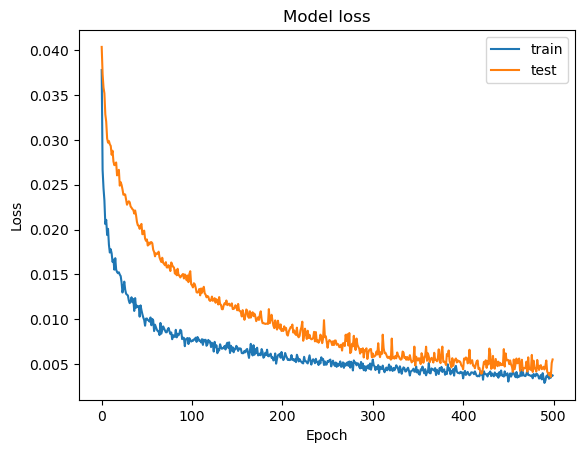

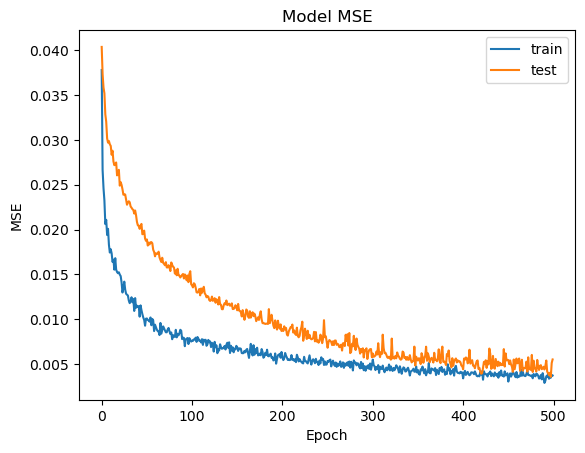

In [52]:
model = Sequential()  # 初始化
input = x.shape[1]
# 隐藏层128
model.add(Dense(128, input_shape=(input,)))  
model.add(Activation('relu'))
# Dropout层用于防止过拟合
model.add(Dropout(0.5))
# 隐藏层128
model.add(Dense(128))
model.add(Activation('relu'))

model.add(Dense(1))
model.add(Activation('linear'))  # 使用线性激活函数

# 使用高效的ADAM优化算法
rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
model.compile(loss='mean_squared_error', optimizer=rmsprop, metrics=['mean_squared_error'])

early_stopping = EarlyStopping(monitor='val_loss', patience=500, verbose=2)

# 训练
history = model.fit(x, y, epochs=500, batch_size=64, shuffle=False, verbose=2,
                   validation_data=(x_test, y_test), callbacks=[early_stopping])

# loss曲线
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# mse曲线
plt.plot(history.history['mean_squared_error'], label='train')
plt.plot(history.history['val_mean_squared_error'], label='test')
plt.title('Model MSE')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Epoch 1/500
7/7 - 1s - loss: 1.3148 - mean_squared_error: 1.3148 - val_loss: 0.1024 - val_mean_squared_error: 0.1024 - 1s/epoch - 212ms/step
Epoch 2/500
7/7 - 0s - loss: 0.6713 - mean_squared_error: 0.6713 - val_loss: 0.1222 - val_mean_squared_error: 0.1222 - 58ms/epoch - 8ms/step
Epoch 3/500
7/7 - 0s - loss: 0.4817 - mean_squared_error: 0.4817 - val_loss: 0.0739 - val_mean_squared_error: 0.0739 - 56ms/epoch - 8ms/step
Epoch 4/500
7/7 - 0s - loss: 0.3919 - mean_squared_error: 0.3919 - val_loss: 0.0980 - val_mean_squared_error: 0.0980 - 54ms/epoch - 8ms/step
Epoch 5/500
7/7 - 0s - loss: 0.3499 - mean_squared_error: 0.3499 - val_loss: 0.0811 - val_mean_squared_error: 0.0811 - 39ms/epoch - 6ms/step
Epoch 6/500
7/7 - 0s - loss: 0.2959 - mean_squared_error: 0.2959 - val_loss: 0.0795 - val_mean_squared_error: 0.0795 - 81ms/epoch - 12ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2692 - mean_squared_error: 0.2692 - val_loss: 0.1916 - val_mean_squared_error: 0.1916 - 56ms/epoch - 8ms/step
Epoch 8/500


Epoch 59/500
7/7 - 0s - loss: 0.0296 - mean_squared_error: 0.0296 - val_loss: 0.0418 - val_mean_squared_error: 0.0418 - 49ms/epoch - 7ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0315 - mean_squared_error: 0.0315 - val_loss: 0.0534 - val_mean_squared_error: 0.0534 - 54ms/epoch - 8ms/step
Epoch 61/500
7/7 - 0s - loss: 0.0382 - mean_squared_error: 0.0382 - val_loss: 0.0365 - val_mean_squared_error: 0.0365 - 55ms/epoch - 8ms/step
Epoch 62/500
7/7 - 0s - loss: 0.0292 - mean_squared_error: 0.0292 - val_loss: 0.0309 - val_mean_squared_error: 0.0309 - 49ms/epoch - 7ms/step
Epoch 63/500
7/7 - 0s - loss: 0.0313 - mean_squared_error: 0.0313 - val_loss: 0.0275 - val_mean_squared_error: 0.0275 - 48ms/epoch - 7ms/step
Epoch 64/500
7/7 - 0s - loss: 0.0334 - mean_squared_error: 0.0334 - val_loss: 0.0268 - val_mean_squared_error: 0.0268 - 58ms/epoch - 8ms/step
Epoch 65/500
7/7 - 0s - loss: 0.0303 - mean_squared_error: 0.0303 - val_loss: 0.0240 - val_mean_squared_error: 0.0240 - 55ms/epoch - 8ms/step
Epoch 

Epoch 117/500
7/7 - 0s - loss: 0.0200 - mean_squared_error: 0.0200 - val_loss: 0.0219 - val_mean_squared_error: 0.0219 - 59ms/epoch - 8ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0169 - mean_squared_error: 0.0169 - val_loss: 0.0238 - val_mean_squared_error: 0.0238 - 53ms/epoch - 8ms/step
Epoch 119/500
7/7 - 0s - loss: 0.0185 - mean_squared_error: 0.0185 - val_loss: 0.0301 - val_mean_squared_error: 0.0301 - 59ms/epoch - 8ms/step
Epoch 120/500
7/7 - 0s - loss: 0.0200 - mean_squared_error: 0.0200 - val_loss: 0.0199 - val_mean_squared_error: 0.0199 - 55ms/epoch - 8ms/step
Epoch 121/500
7/7 - 0s - loss: 0.0161 - mean_squared_error: 0.0161 - val_loss: 0.0192 - val_mean_squared_error: 0.0192 - 61ms/epoch - 9ms/step
Epoch 122/500
7/7 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 55ms/epoch - 8ms/step
Epoch 123/500
7/7 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0220 - val_mean_squared_error: 0.0220 - 53ms/epoch - 8ms/step

Epoch 175/500
7/7 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0232 - val_mean_squared_error: 0.0232 - 54ms/epoch - 8ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0162 - mean_squared_error: 0.0162 - val_loss: 0.0300 - val_mean_squared_error: 0.0300 - 54ms/epoch - 8ms/step
Epoch 177/500
7/7 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 56ms/epoch - 8ms/step
Epoch 178/500
7/7 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0211 - val_mean_squared_error: 0.0211 - 71ms/epoch - 10ms/step
Epoch 179/500
7/7 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 73ms/epoch - 10ms/step
Epoch 180/500
7/7 - 0s - loss: 0.0144 - mean_squared_error: 0.0144 - val_loss: 0.0186 - val_mean_squared_error: 0.0186 - 59ms/epoch - 8ms/step
Epoch 181/500
7/7 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 53ms/epoch - 8ms/st

Epoch 233/500
7/7 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 53ms/epoch - 8ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 54ms/epoch - 8ms/step
Epoch 235/500
7/7 - 0s - loss: 0.0118 - mean_squared_error: 0.0118 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 58ms/epoch - 8ms/step
Epoch 236/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0157 - val_mean_squared_error: 0.0157 - 59ms/epoch - 8ms/step
Epoch 237/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 54ms/epoch - 8ms/step
Epoch 238/500
7/7 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0177 - val_mean_squared_error: 0.0177 - 55ms/epoch - 8ms/step
Epoch 239/500
7/7 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0135 - val_mean_squared_error: 0.0135 - 54ms/epoch - 8ms/step

Epoch 291/500
7/7 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 50ms/epoch - 7ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 49ms/epoch - 7ms/step
Epoch 293/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 72ms/epoch - 10ms/step
Epoch 294/500
7/7 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 52ms/epoch - 7ms/step
Epoch 295/500
7/7 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 62ms/epoch - 9ms/step
Epoch 296/500
7/7 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 49ms/epoch - 7ms/step
Epoch 297/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0150 - val_mean_squared_error: 0.0150 - 58ms/epoch - 8ms/ste

Epoch 349/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 53ms/epoch - 8ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 52ms/epoch - 7ms/step
Epoch 351/500
7/7 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0097 - val_mean_squared_error: 0.0097 - 52ms/epoch - 7ms/step
Epoch 352/500
7/7 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 53ms/epoch - 8ms/step
Epoch 353/500
7/7 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 56ms/epoch - 8ms/step
Epoch 354/500
7/7 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0150 - val_mean_squared_error: 0.0150 - 48ms/epoch - 7ms/step
Epoch 355/500
7/7 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 56ms/epoch - 8ms/step

Epoch 407/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 49ms/epoch - 7ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 53ms/epoch - 8ms/step
Epoch 409/500
7/7 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0088 - val_mean_squared_error: 0.0088 - 56ms/epoch - 8ms/step
Epoch 410/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 48ms/epoch - 7ms/step
Epoch 411/500
7/7 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 55ms/epoch - 8ms/step
Epoch 412/500
7/7 - 0s - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 48ms/epoch - 7ms/step
Epoch 413/500
7/7 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 49ms/epoch - 7ms/step

Epoch 465/500
7/7 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 37ms/epoch - 5ms/step
Epoch 466/500
7/7 - 0s - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 58ms/epoch - 8ms/step
Epoch 467/500
7/7 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 48ms/epoch - 7ms/step
Epoch 468/500
7/7 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 49ms/epoch - 7ms/step
Epoch 469/500
7/7 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0113 - val_mean_squared_error: 0.0113 - 43ms/epoch - 6ms/step
Epoch 470/500
7/7 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 54ms/epoch - 8ms/step
Epoch 471/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 86ms/epoch - 12ms/ste

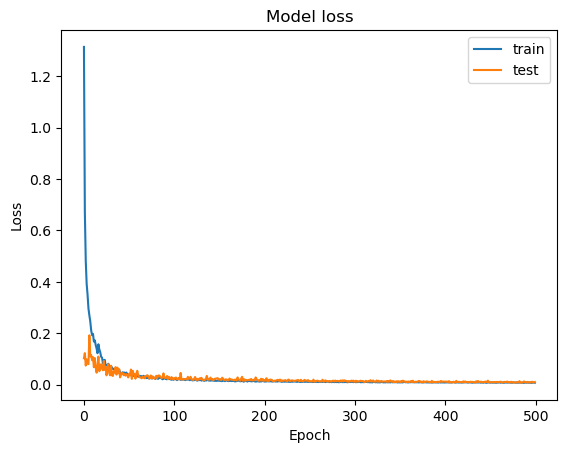

3/3 [==============================] - 0s 3ms/step
MSE: 0.01
R2: 0.77
Epoch 1/500
7/7 - 1s - loss: 1.0685 - mean_squared_error: 1.0685 - val_loss: 0.0870 - val_mean_squared_error: 0.0870 - 1s/epoch - 178ms/step
Epoch 2/500
7/7 - 0s - loss: 0.5209 - mean_squared_error: 0.5209 - val_loss: 0.1522 - val_mean_squared_error: 0.1522 - 48ms/epoch - 7ms/step
Epoch 3/500
7/7 - 0s - loss: 0.4441 - mean_squared_error: 0.4441 - val_loss: 0.0987 - val_mean_squared_error: 0.0987 - 54ms/epoch - 8ms/step
Epoch 4/500
7/7 - 0s - loss: 0.3795 - mean_squared_error: 0.3795 - val_loss: 0.1131 - val_mean_squared_error: 0.1131 - 63ms/epoch - 9ms/step
Epoch 5/500
7/7 - 0s - loss: 0.3115 - mean_squared_error: 0.3115 - val_loss: 0.0689 - val_mean_squared_error: 0.0689 - 52ms/epoch - 7ms/step
Epoch 6/500
7/7 - 0s - loss: 0.2498 - mean_squared_error: 0.2498 - val_loss: 0.0761 - val_mean_squared_error: 0.0761 - 43ms/epoch - 6ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2415 - mean_squared_error: 0.2415 - val_loss: 0.0853 

Epoch 59/500
7/7 - 0s - loss: 0.0281 - mean_squared_error: 0.0281 - val_loss: 0.0271 - val_mean_squared_error: 0.0271 - 60ms/epoch - 9ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0287 - mean_squared_error: 0.0287 - val_loss: 0.0397 - val_mean_squared_error: 0.0397 - 39ms/epoch - 6ms/step
Epoch 61/500
7/7 - 0s - loss: 0.0384 - mean_squared_error: 0.0384 - val_loss: 0.0389 - val_mean_squared_error: 0.0389 - 46ms/epoch - 7ms/step
Epoch 62/500
7/7 - 0s - loss: 0.0265 - mean_squared_error: 0.0265 - val_loss: 0.0484 - val_mean_squared_error: 0.0484 - 55ms/epoch - 8ms/step
Epoch 63/500
7/7 - 0s - loss: 0.0259 - mean_squared_error: 0.0259 - val_loss: 0.0283 - val_mean_squared_error: 0.0283 - 34ms/epoch - 5ms/step
Epoch 64/500
7/7 - 0s - loss: 0.0290 - mean_squared_error: 0.0290 - val_loss: 0.0532 - val_mean_squared_error: 0.0532 - 54ms/epoch - 8ms/step
Epoch 65/500
7/7 - 0s - loss: 0.0266 - mean_squared_error: 0.0266 - val_loss: 0.0313 - val_mean_squared_error: 0.0313 - 54ms/epoch - 8ms/step
Epoch 

Epoch 117/500
7/7 - 0s - loss: 0.0157 - mean_squared_error: 0.0157 - val_loss: 0.0240 - val_mean_squared_error: 0.0240 - 51ms/epoch - 7ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0225 - val_mean_squared_error: 0.0225 - 55ms/epoch - 8ms/step
Epoch 119/500
7/7 - 0s - loss: 0.0132 - mean_squared_error: 0.0132 - val_loss: 0.0188 - val_mean_squared_error: 0.0188 - 51ms/epoch - 7ms/step
Epoch 120/500
7/7 - 0s - loss: 0.0198 - mean_squared_error: 0.0198 - val_loss: 0.0209 - val_mean_squared_error: 0.0209 - 53ms/epoch - 8ms/step
Epoch 121/500
7/7 - 0s - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0235 - val_mean_squared_error: 0.0235 - 52ms/epoch - 7ms/step
Epoch 122/500
7/7 - 0s - loss: 0.0144 - mean_squared_error: 0.0144 - val_loss: 0.0238 - val_mean_squared_error: 0.0238 - 51ms/epoch - 7ms/step
Epoch 123/500
7/7 - 0s - loss: 0.0150 - mean_squared_error: 0.0150 - val_loss: 0.0199 - val_mean_squared_error: 0.0199 - 55ms/epoch - 8ms/step

Epoch 175/500
7/7 - 0s - loss: 0.0144 - mean_squared_error: 0.0144 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 35ms/epoch - 5ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 31ms/epoch - 4ms/step
Epoch 177/500
7/7 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 53ms/epoch - 8ms/step
Epoch 178/500
7/7 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0205 - val_mean_squared_error: 0.0205 - 46ms/epoch - 7ms/step
Epoch 179/500
7/7 - 0s - loss: 0.0134 - mean_squared_error: 0.0134 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 71ms/epoch - 10ms/step
Epoch 180/500
7/7 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0186 - val_mean_squared_error: 0.0186 - 39ms/epoch - 6ms/step
Epoch 181/500
7/7 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 84ms/epoch - 12ms/st

Epoch 233/500
7/7 - 0s - loss: 0.0119 - mean_squared_error: 0.0119 - val_loss: 0.0205 - val_mean_squared_error: 0.0205 - 45ms/epoch - 6ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 46ms/epoch - 7ms/step
Epoch 235/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0169 - val_mean_squared_error: 0.0169 - 51ms/epoch - 7ms/step
Epoch 236/500
7/7 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0103 - val_mean_squared_error: 0.0103 - 43ms/epoch - 6ms/step
Epoch 237/500
7/7 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 55ms/epoch - 8ms/step
Epoch 238/500
7/7 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 46ms/epoch - 7ms/step
Epoch 239/500
7/7 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0193 - val_mean_squared_error: 0.0193 - 47ms/epoch - 7ms/step

Epoch 291/500
7/7 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0176 - val_mean_squared_error: 0.0176 - 47ms/epoch - 7ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 75ms/epoch - 11ms/step
Epoch 293/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 55ms/epoch - 8ms/step
Epoch 294/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 43ms/epoch - 6ms/step
Epoch 295/500
7/7 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 54ms/epoch - 8ms/step
Epoch 296/500
7/7 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 57ms/epoch - 8ms/step
Epoch 297/500
7/7 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 47ms/epoch - 7ms/ste

Epoch 349/500
7/7 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0138 - val_mean_squared_error: 0.0138 - 47ms/epoch - 7ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 64ms/epoch - 9ms/step
Epoch 351/500
7/7 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 38ms/epoch - 5ms/step
Epoch 352/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 79ms/epoch - 11ms/step
Epoch 353/500
7/7 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 42ms/epoch - 6ms/step
Epoch 354/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 47ms/epoch - 7ms/step
Epoch 355/500
7/7 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 51ms/epoch - 7ms/ste

Epoch 407/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 54ms/epoch - 8ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 44ms/epoch - 6ms/step
Epoch 409/500
7/7 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 47ms/epoch - 7ms/step
Epoch 410/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 49ms/epoch - 7ms/step
Epoch 411/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 47ms/epoch - 7ms/step
Epoch 412/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 65ms/epoch - 9ms/step
Epoch 413/500
7/7 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 40ms/epoch - 6ms/step

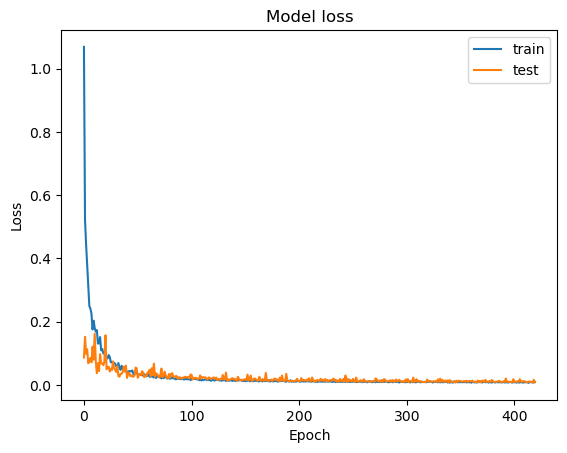

3/3 [==============================] - 0s 0s/step
MSE: 0.01
R2: 0.79
Epoch 1/500
7/7 - 1s - loss: 1.3441 - mean_squared_error: 1.3441 - val_loss: 0.1338 - val_mean_squared_error: 0.1338 - 1s/epoch - 180ms/step
Epoch 2/500
7/7 - 0s - loss: 0.6830 - mean_squared_error: 0.6830 - val_loss: 0.1598 - val_mean_squared_error: 0.1598 - 47ms/epoch - 7ms/step
Epoch 3/500
7/7 - 0s - loss: 0.4798 - mean_squared_error: 0.4798 - val_loss: 0.1535 - val_mean_squared_error: 0.1535 - 73ms/epoch - 10ms/step
Epoch 4/500
7/7 - 0s - loss: 0.3496 - mean_squared_error: 0.3496 - val_loss: 0.1681 - val_mean_squared_error: 0.1681 - 52ms/epoch - 7ms/step
Epoch 5/500
7/7 - 0s - loss: 0.3710 - mean_squared_error: 0.3710 - val_loss: 0.1599 - val_mean_squared_error: 0.1599 - 49ms/epoch - 7ms/step
Epoch 6/500
7/7 - 0s - loss: 0.2835 - mean_squared_error: 0.2835 - val_loss: 0.1256 - val_mean_squared_error: 0.1256 - 47ms/epoch - 7ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2412 - mean_squared_error: 0.2412 - val_loss: 0.0980 

Epoch 59/500
7/7 - 0s - loss: 0.0271 - mean_squared_error: 0.0271 - val_loss: 0.0362 - val_mean_squared_error: 0.0362 - 87ms/epoch - 12ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0319 - mean_squared_error: 0.0319 - val_loss: 0.0319 - val_mean_squared_error: 0.0319 - 126ms/epoch - 18ms/step
Epoch 61/500
7/7 - 0s - loss: 0.0233 - mean_squared_error: 0.0233 - val_loss: 0.0296 - val_mean_squared_error: 0.0296 - 94ms/epoch - 13ms/step
Epoch 62/500
7/7 - 0s - loss: 0.0235 - mean_squared_error: 0.0235 - val_loss: 0.0411 - val_mean_squared_error: 0.0411 - 79ms/epoch - 11ms/step
Epoch 63/500
7/7 - 0s - loss: 0.0298 - mean_squared_error: 0.0298 - val_loss: 0.0297 - val_mean_squared_error: 0.0297 - 94ms/epoch - 13ms/step
Epoch 64/500
7/7 - 0s - loss: 0.0251 - mean_squared_error: 0.0251 - val_loss: 0.0308 - val_mean_squared_error: 0.0308 - 89ms/epoch - 13ms/step
Epoch 65/500
7/7 - 0s - loss: 0.0232 - mean_squared_error: 0.0232 - val_loss: 0.0322 - val_mean_squared_error: 0.0322 - 78ms/epoch - 11ms/ste

Epoch 117/500
7/7 - 0s - loss: 0.0133 - mean_squared_error: 0.0133 - val_loss: 0.0285 - val_mean_squared_error: 0.0285 - 94ms/epoch - 13ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0164 - mean_squared_error: 0.0164 - val_loss: 0.0213 - val_mean_squared_error: 0.0213 - 47ms/epoch - 7ms/step
Epoch 119/500
7/7 - 0s - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0188 - val_mean_squared_error: 0.0188 - 63ms/epoch - 9ms/step
Epoch 120/500
7/7 - 0s - loss: 0.0137 - mean_squared_error: 0.0137 - val_loss: 0.0228 - val_mean_squared_error: 0.0228 - 63ms/epoch - 9ms/step
Epoch 121/500
7/7 - 0s - loss: 0.0191 - mean_squared_error: 0.0191 - val_loss: 0.0235 - val_mean_squared_error: 0.0235 - 47ms/epoch - 7ms/step
Epoch 122/500
7/7 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0206 - val_mean_squared_error: 0.0206 - 63ms/epoch - 9ms/step
Epoch 123/500
7/7 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0287 - val_mean_squared_error: 0.0287 - 78ms/epoch - 11ms/st

7/7 - 0s - loss: 0.0139 - mean_squared_error: 0.0139 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 79ms/epoch - 11ms/step
Epoch 175/500
7/7 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0177 - val_mean_squared_error: 0.0177 - 79ms/epoch - 11ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0236 - val_mean_squared_error: 0.0236 - 94ms/epoch - 13ms/step
Epoch 177/500
7/7 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0220 - val_mean_squared_error: 0.0220 - 62ms/epoch - 9ms/step
Epoch 178/500
7/7 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 79ms/epoch - 11ms/step
Epoch 179/500
7/7 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 63ms/epoch - 9ms/step
Epoch 180/500
7/7 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0305 - val_mean_squared_error: 0.0305 - 79ms/epoch - 11ms/step
Epoch 18

Epoch 231/500
7/7 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 88ms/epoch - 13ms/step
Epoch 232/500
7/7 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0228 - val_mean_squared_error: 0.0228 - 91ms/epoch - 13ms/step
Epoch 233/500
7/7 - 0s - loss: 0.0118 - mean_squared_error: 0.0118 - val_loss: 0.0200 - val_mean_squared_error: 0.0200 - 119ms/epoch - 17ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0177 - val_mean_squared_error: 0.0177 - 96ms/epoch - 14ms/step
Epoch 235/500
7/7 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0138 - val_mean_squared_error: 0.0138 - 90ms/epoch - 13ms/step
Epoch 236/500
7/7 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0238 - val_mean_squared_error: 0.0238 - 80ms/epoch - 11ms/step
Epoch 237/500
7/7 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 90ms/epoch - 1

Epoch 288/500
7/7 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 63ms/epoch - 9ms/step
Epoch 289/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 59ms/epoch - 8ms/step
Epoch 290/500
7/7 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 102ms/epoch - 15ms/step
Epoch 291/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 93ms/epoch - 13ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0169 - val_mean_squared_error: 0.0169 - 81ms/epoch - 12ms/step
Epoch 293/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 90ms/epoch - 13ms/step
Epoch 294/500
7/7 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0210 - val_mean_squared_error: 0.0210 - 106ms/epoch - 15

Epoch 346/500
7/7 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 72ms/epoch - 10ms/step
Epoch 347/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 63ms/epoch - 9ms/step
Epoch 348/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0102 - val_mean_squared_error: 0.0102 - 47ms/epoch - 7ms/step
Epoch 349/500
7/7 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 45ms/epoch - 6ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 54ms/epoch - 8ms/step
Epoch 351/500
7/7 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0103 - val_mean_squared_error: 0.0103 - 78ms/epoch - 11ms/step
Epoch 352/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 68ms/epoch - 10ms/s

Epoch 404/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 55ms/epoch - 8ms/step
Epoch 405/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 52ms/epoch - 7ms/step
Epoch 406/500
7/7 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0201 - val_mean_squared_error: 0.0201 - 44ms/epoch - 6ms/step
Epoch 407/500
7/7 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 83ms/epoch - 12ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 100ms/epoch - 14ms/step
Epoch 409/500
7/7 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 48ms/epoch - 7ms/step
Epoch 410/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 60ms/epoch - 9ms/s

Epoch 462/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - 47ms/epoch - 7ms/step
Epoch 463/500
7/7 - 0s - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 61ms/epoch - 9ms/step
Epoch 464/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 55ms/epoch - 8ms/step
Epoch 465/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 50ms/epoch - 7ms/step
Epoch 466/500
7/7 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 54ms/epoch - 8ms/step
Epoch 467/500
7/7 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 54ms/epoch - 8ms/step
Epoch 468/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 51ms/epoch - 7ms/step

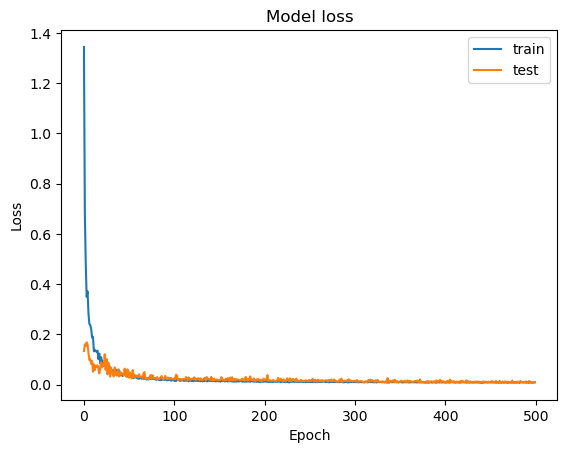

3/3 [==============================] - 0s 8ms/step
MSE: 0.01
R2: 0.78
Epoch 1/500
7/7 - 1s - loss: 1.1011 - mean_squared_error: 1.1011 - val_loss: 0.0414 - val_mean_squared_error: 0.0414 - 1s/epoch - 187ms/step
Epoch 2/500
7/7 - 0s - loss: 0.6907 - mean_squared_error: 0.6907 - val_loss: 0.0502 - val_mean_squared_error: 0.0502 - 51ms/epoch - 7ms/step
Epoch 3/500
7/7 - 0s - loss: 0.4550 - mean_squared_error: 0.4550 - val_loss: 0.0611 - val_mean_squared_error: 0.0611 - 54ms/epoch - 8ms/step
Epoch 4/500
7/7 - 0s - loss: 0.3753 - mean_squared_error: 0.3753 - val_loss: 0.1395 - val_mean_squared_error: 0.1395 - 60ms/epoch - 9ms/step
Epoch 5/500
7/7 - 0s - loss: 0.3068 - mean_squared_error: 0.3068 - val_loss: 0.1353 - val_mean_squared_error: 0.1353 - 55ms/epoch - 8ms/step
Epoch 6/500
7/7 - 0s - loss: 0.2934 - mean_squared_error: 0.2934 - val_loss: 0.1118 - val_mean_squared_error: 0.1118 - 53ms/epoch - 8ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2366 - mean_squared_error: 0.2366 - val_loss: 0.0870 

Epoch 59/500
7/7 - 0s - loss: 0.0320 - mean_squared_error: 0.0320 - val_loss: 0.0235 - val_mean_squared_error: 0.0235 - 63ms/epoch - 9ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0278 - mean_squared_error: 0.0278 - val_loss: 0.0388 - val_mean_squared_error: 0.0388 - 56ms/epoch - 8ms/step
Epoch 61/500
7/7 - 0s - loss: 0.0356 - mean_squared_error: 0.0356 - val_loss: 0.0285 - val_mean_squared_error: 0.0285 - 44ms/epoch - 6ms/step
Epoch 62/500
7/7 - 0s - loss: 0.0368 - mean_squared_error: 0.0368 - val_loss: 0.0527 - val_mean_squared_error: 0.0527 - 45ms/epoch - 6ms/step
Epoch 63/500
7/7 - 0s - loss: 0.0312 - mean_squared_error: 0.0312 - val_loss: 0.0225 - val_mean_squared_error: 0.0225 - 52ms/epoch - 7ms/step
Epoch 64/500
7/7 - 0s - loss: 0.0249 - mean_squared_error: 0.0249 - val_loss: 0.0332 - val_mean_squared_error: 0.0332 - 50ms/epoch - 7ms/step
Epoch 65/500
7/7 - 0s - loss: 0.0257 - mean_squared_error: 0.0257 - val_loss: 0.0281 - val_mean_squared_error: 0.0281 - 55ms/epoch - 8ms/step
Epoch 

Epoch 117/500
7/7 - 0s - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0371 - val_mean_squared_error: 0.0371 - 57ms/epoch - 8ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0202 - mean_squared_error: 0.0202 - val_loss: 0.0210 - val_mean_squared_error: 0.0210 - 42ms/epoch - 6ms/step
Epoch 119/500
7/7 - 0s - loss: 0.0194 - mean_squared_error: 0.0194 - val_loss: 0.0194 - val_mean_squared_error: 0.0194 - 43ms/epoch - 6ms/step
Epoch 120/500
7/7 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0182 - val_mean_squared_error: 0.0182 - 49ms/epoch - 7ms/step
Epoch 121/500
7/7 - 0s - loss: 0.0181 - mean_squared_error: 0.0181 - val_loss: 0.0226 - val_mean_squared_error: 0.0226 - 55ms/epoch - 8ms/step
Epoch 122/500
7/7 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0349 - val_mean_squared_error: 0.0349 - 54ms/epoch - 8ms/step
Epoch 123/500
7/7 - 0s - loss: 0.0161 - mean_squared_error: 0.0161 - val_loss: 0.0298 - val_mean_squared_error: 0.0298 - 55ms/epoch - 8ms/step

Epoch 175/500
7/7 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 53ms/epoch - 8ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0224 - val_mean_squared_error: 0.0224 - 68ms/epoch - 10ms/step
Epoch 177/500
7/7 - 0s - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0227 - val_mean_squared_error: 0.0227 - 61ms/epoch - 9ms/step
Epoch 178/500
7/7 - 0s - loss: 0.0143 - mean_squared_error: 0.0143 - val_loss: 0.0196 - val_mean_squared_error: 0.0196 - 61ms/epoch - 9ms/step
Epoch 179/500
7/7 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0166 - val_mean_squared_error: 0.0166 - 60ms/epoch - 9ms/step
Epoch 180/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0203 - val_mean_squared_error: 0.0203 - 62ms/epoch - 9ms/step
Epoch 181/500
7/7 - 0s - loss: 0.0150 - mean_squared_error: 0.0150 - val_loss: 0.0174 - val_mean_squared_error: 0.0174 - 56ms/epoch - 8ms/ste

Epoch 233/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 109ms/epoch - 16ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 50ms/epoch - 7ms/step
Epoch 235/500
7/7 - 0s - loss: 0.0145 - mean_squared_error: 0.0145 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 48ms/epoch - 7ms/step
Epoch 236/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 49ms/epoch - 7ms/step
Epoch 237/500
7/7 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0171 - val_mean_squared_error: 0.0171 - 66ms/epoch - 9ms/step
Epoch 238/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0169 - val_mean_squared_error: 0.0169 - 69ms/epoch - 10ms/step
Epoch 239/500
7/7 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 51ms/epoch - 7ms/s

Epoch 291/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 50ms/epoch - 7ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0185 - val_mean_squared_error: 0.0185 - 56ms/epoch - 8ms/step
Epoch 293/500
7/7 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 35ms/epoch - 5ms/step
Epoch 294/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 36ms/epoch - 5ms/step
Epoch 295/500
7/7 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 61ms/epoch - 9ms/step
Epoch 296/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 63ms/epoch - 9ms/step
Epoch 297/500
7/7 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0193 - val_mean_squared_error: 0.0193 - 74ms/epoch - 11ms/ste

Epoch 349/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 62ms/epoch - 9ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 51ms/epoch - 7ms/step
Epoch 351/500
7/7 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 63ms/epoch - 9ms/step
Epoch 352/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0133 - val_mean_squared_error: 0.0133 - 55ms/epoch - 8ms/step
Epoch 353/500
7/7 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 54ms/epoch - 8ms/step
Epoch 354/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 54ms/epoch - 8ms/step
Epoch 355/500
7/7 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 67ms/epoch - 10ms/ste

Epoch 407/500
7/7 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 54ms/epoch - 8ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 73ms/epoch - 10ms/step
Epoch 409/500
7/7 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 60ms/epoch - 9ms/step
Epoch 410/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 56ms/epoch - 8ms/step
Epoch 411/500
7/7 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 47ms/epoch - 7ms/step
Epoch 412/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 48ms/epoch - 7ms/step
Epoch 413/500
7/7 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 47ms/epoch - 7ms/ste

Epoch 465/500
7/7 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 50ms/epoch - 7ms/step
Epoch 466/500
7/7 - 0s - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0210 - val_mean_squared_error: 0.0210 - 52ms/epoch - 7ms/step
Epoch 467/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 54ms/epoch - 8ms/step
Epoch 468/500
7/7 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 62ms/epoch - 9ms/step
Epoch 469/500
7/7 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0183 - val_mean_squared_error: 0.0183 - 40ms/epoch - 6ms/step
Epoch 470/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0076 - val_mean_squared_error: 0.0076 - 55ms/epoch - 8ms/step
Epoch 471/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0172 - val_mean_squared_error: 0.0172 - 94ms/epoch - 13ms/ste

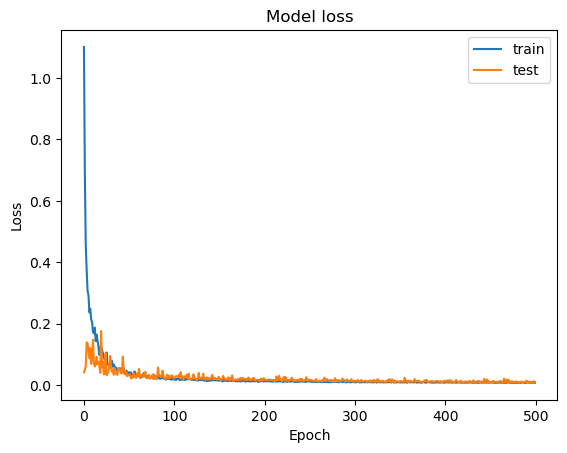

3/3 [==============================] - 0s 0s/step
MSE: 0.01
R2: 0.75
Epoch 1/500
7/7 - 1s - loss: 1.1628 - mean_squared_error: 1.1628 - val_loss: 0.0937 - val_mean_squared_error: 0.0937 - 1s/epoch - 190ms/step
Epoch 2/500
7/7 - 0s - loss: 0.6458 - mean_squared_error: 0.6458 - val_loss: 0.0786 - val_mean_squared_error: 0.0786 - 60ms/epoch - 9ms/step
Epoch 3/500
7/7 - 0s - loss: 0.4443 - mean_squared_error: 0.4443 - val_loss: 0.0698 - val_mean_squared_error: 0.0698 - 64ms/epoch - 9ms/step
Epoch 4/500
7/7 - 0s - loss: 0.3753 - mean_squared_error: 0.3753 - val_loss: 0.0875 - val_mean_squared_error: 0.0875 - 44ms/epoch - 6ms/step
Epoch 5/500
7/7 - 0s - loss: 0.3392 - mean_squared_error: 0.3392 - val_loss: 0.0945 - val_mean_squared_error: 0.0945 - 79ms/epoch - 11ms/step
Epoch 6/500
7/7 - 0s - loss: 0.2805 - mean_squared_error: 0.2805 - val_loss: 0.1553 - val_mean_squared_error: 0.1553 - 63ms/epoch - 9ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2784 - mean_squared_error: 0.2784 - val_loss: 0.2174 

Epoch 59/500
7/7 - 0s - loss: 0.0318 - mean_squared_error: 0.0318 - val_loss: 0.0245 - val_mean_squared_error: 0.0245 - 40ms/epoch - 6ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0336 - mean_squared_error: 0.0336 - val_loss: 0.0220 - val_mean_squared_error: 0.0220 - 39ms/epoch - 6ms/step
Epoch 61/500
7/7 - 0s - loss: 0.0329 - mean_squared_error: 0.0329 - val_loss: 0.0256 - val_mean_squared_error: 0.0256 - 53ms/epoch - 8ms/step
Epoch 62/500
7/7 - 0s - loss: 0.0260 - mean_squared_error: 0.0260 - val_loss: 0.0265 - val_mean_squared_error: 0.0265 - 55ms/epoch - 8ms/step
Epoch 63/500
7/7 - 0s - loss: 0.0299 - mean_squared_error: 0.0299 - val_loss: 0.0231 - val_mean_squared_error: 0.0231 - 57ms/epoch - 8ms/step
Epoch 64/500
7/7 - 0s - loss: 0.0306 - mean_squared_error: 0.0306 - val_loss: 0.0256 - val_mean_squared_error: 0.0256 - 47ms/epoch - 7ms/step
Epoch 65/500
7/7 - 0s - loss: 0.0248 - mean_squared_error: 0.0248 - val_loss: 0.0207 - val_mean_squared_error: 0.0207 - 44ms/epoch - 6ms/step
Epoch 

Epoch 117/500
7/7 - 0s - loss: 0.0146 - mean_squared_error: 0.0146 - val_loss: 0.0176 - val_mean_squared_error: 0.0176 - 48ms/epoch - 7ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0188 - mean_squared_error: 0.0188 - val_loss: 0.0232 - val_mean_squared_error: 0.0232 - 49ms/epoch - 7ms/step
Epoch 119/500
7/7 - 0s - loss: 0.0135 - mean_squared_error: 0.0135 - val_loss: 0.0149 - val_mean_squared_error: 0.0149 - 55ms/epoch - 8ms/step
Epoch 120/500
7/7 - 0s - loss: 0.0147 - mean_squared_error: 0.0147 - val_loss: 0.0206 - val_mean_squared_error: 0.0206 - 54ms/epoch - 8ms/step
Epoch 121/500
7/7 - 0s - loss: 0.0193 - mean_squared_error: 0.0193 - val_loss: 0.0216 - val_mean_squared_error: 0.0216 - 53ms/epoch - 8ms/step
Epoch 122/500
7/7 - 0s - loss: 0.0148 - mean_squared_error: 0.0148 - val_loss: 0.0271 - val_mean_squared_error: 0.0271 - 57ms/epoch - 8ms/step
Epoch 123/500
7/7 - 0s - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0189 - val_mean_squared_error: 0.0189 - 53ms/epoch - 8ms/step

Epoch 175/500
7/7 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0297 - val_mean_squared_error: 0.0297 - 50ms/epoch - 7ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 54ms/epoch - 8ms/step
Epoch 177/500
7/7 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0191 - val_mean_squared_error: 0.0191 - 60ms/epoch - 9ms/step
Epoch 178/500
7/7 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0272 - val_mean_squared_error: 0.0272 - 53ms/epoch - 8ms/step
Epoch 179/500
7/7 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0166 - val_mean_squared_error: 0.0166 - 55ms/epoch - 8ms/step
Epoch 180/500
7/7 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0251 - val_mean_squared_error: 0.0251 - 56ms/epoch - 8ms/step
Epoch 181/500
7/7 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 43ms/epoch - 6ms/step

Epoch 233/500
7/7 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0212 - val_mean_squared_error: 0.0212 - 49ms/epoch - 7ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0133 - val_mean_squared_error: 0.0133 - 49ms/epoch - 7ms/step
Epoch 235/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 60ms/epoch - 9ms/step
Epoch 236/500
7/7 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0318 - val_mean_squared_error: 0.0318 - 53ms/epoch - 8ms/step
Epoch 237/500
7/7 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 51ms/epoch - 7ms/step
Epoch 238/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 49ms/epoch - 7ms/step
Epoch 239/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0178 - val_mean_squared_error: 0.0178 - 48ms/epoch - 7ms/step

Epoch 291/500
7/7 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 48ms/epoch - 7ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0102 - val_mean_squared_error: 0.0102 - 55ms/epoch - 8ms/step
Epoch 293/500
7/7 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0153 - val_mean_squared_error: 0.0153 - 43ms/epoch - 6ms/step
Epoch 294/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 50ms/epoch - 7ms/step
Epoch 295/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0195 - val_mean_squared_error: 0.0195 - 49ms/epoch - 7ms/step
Epoch 296/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 44ms/epoch - 6ms/step
Epoch 297/500
7/7 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 56ms/epoch - 8ms/step

Epoch 349/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 49ms/epoch - 7ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 51ms/epoch - 7ms/step
Epoch 351/500
7/7 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 52ms/epoch - 7ms/step
Epoch 352/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0124 - val_mean_squared_error: 0.0124 - 56ms/epoch - 8ms/step
Epoch 353/500
7/7 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 60ms/epoch - 9ms/step
Epoch 354/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 49ms/epoch - 7ms/step
Epoch 355/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0088 - val_mean_squared_error: 0.0088 - 51ms/epoch - 7ms/step

Epoch 407/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 64ms/epoch - 9ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 82ms/epoch - 12ms/step
Epoch 409/500
7/7 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 47ms/epoch - 7ms/step
Epoch 410/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 56ms/epoch - 8ms/step
Epoch 411/500
7/7 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 54ms/epoch - 8ms/step
Epoch 412/500
7/7 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 44ms/epoch - 6ms/step
Epoch 413/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 55ms/epoch - 8ms/ste

Epoch 465/500
7/7 - 0s - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0158 - val_mean_squared_error: 0.0158 - 84ms/epoch - 12ms/step
Epoch 466/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 63ms/epoch - 9ms/step
Epoch 467/500
7/7 - 0s - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0073 - val_mean_squared_error: 0.0073 - 60ms/epoch - 9ms/step
Epoch 468/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 50ms/epoch - 7ms/step
Epoch 469/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 73ms/epoch - 10ms/step
Epoch 470/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0075 - val_mean_squared_error: 0.0075 - 73ms/epoch - 10ms/step
Epoch 471/500
7/7 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 56ms/epoch - 8ms/s

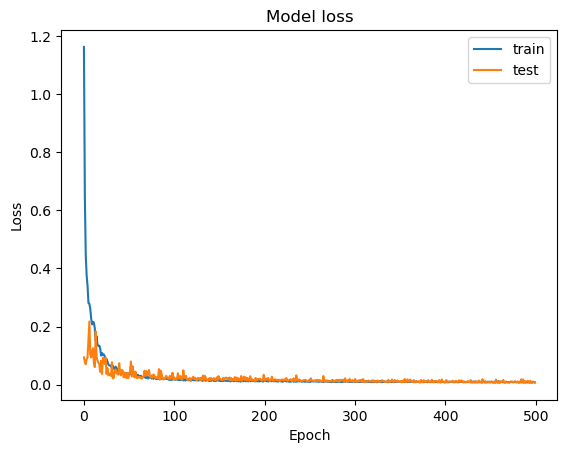

3/3 [==============================] - 0s 7ms/step
MSE: 0.01
R2: 0.84
Epoch 1/500
7/7 - 1s - loss: 1.6083 - mean_squared_error: 1.6083 - val_loss: 0.0621 - val_mean_squared_error: 0.0621 - 1s/epoch - 204ms/step
Epoch 2/500
7/7 - 0s - loss: 0.7857 - mean_squared_error: 0.7857 - val_loss: 0.1095 - val_mean_squared_error: 0.1095 - 61ms/epoch - 9ms/step
Epoch 3/500
7/7 - 0s - loss: 0.5507 - mean_squared_error: 0.5507 - val_loss: 0.1302 - val_mean_squared_error: 0.1302 - 48ms/epoch - 7ms/step
Epoch 4/500
7/7 - 0s - loss: 0.4389 - mean_squared_error: 0.4389 - val_loss: 0.0866 - val_mean_squared_error: 0.0866 - 45ms/epoch - 6ms/step
Epoch 5/500
7/7 - 0s - loss: 0.4300 - mean_squared_error: 0.4300 - val_loss: 0.1396 - val_mean_squared_error: 0.1396 - 55ms/epoch - 8ms/step
Epoch 6/500
7/7 - 0s - loss: 0.3337 - mean_squared_error: 0.3337 - val_loss: 0.1295 - val_mean_squared_error: 0.1295 - 87ms/epoch - 12ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2884 - mean_squared_error: 0.2884 - val_loss: 0.1339

Epoch 54/500
7/7 - 0s - loss: 0.0380 - mean_squared_error: 0.0380 - val_loss: 0.0623 - val_mean_squared_error: 0.0623 - 54ms/epoch - 8ms/step
Epoch 55/500
7/7 - 0s - loss: 0.0414 - mean_squared_error: 0.0414 - val_loss: 0.0342 - val_mean_squared_error: 0.0342 - 54ms/epoch - 8ms/step
Epoch 56/500
7/7 - 0s - loss: 0.0368 - mean_squared_error: 0.0368 - val_loss: 0.0565 - val_mean_squared_error: 0.0565 - 55ms/epoch - 8ms/step
Epoch 57/500
7/7 - 0s - loss: 0.0446 - mean_squared_error: 0.0446 - val_loss: 0.0350 - val_mean_squared_error: 0.0350 - 96ms/epoch - 14ms/step
Epoch 58/500
7/7 - 0s - loss: 0.0412 - mean_squared_error: 0.0412 - val_loss: 0.0352 - val_mean_squared_error: 0.0352 - 79ms/epoch - 11ms/step
Epoch 59/500
7/7 - 0s - loss: 0.0340 - mean_squared_error: 0.0340 - val_loss: 0.0474 - val_mean_squared_error: 0.0474 - 47ms/epoch - 7ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0349 - mean_squared_error: 0.0349 - val_loss: 0.0415 - val_mean_squared_error: 0.0415 - 57ms/epoch - 8ms/step
Epoc

Epoch 112/500
7/7 - 0s - loss: 0.0209 - mean_squared_error: 0.0209 - val_loss: 0.0245 - val_mean_squared_error: 0.0245 - 47ms/epoch - 7ms/step
Epoch 113/500
7/7 - 0s - loss: 0.0187 - mean_squared_error: 0.0187 - val_loss: 0.0315 - val_mean_squared_error: 0.0315 - 46ms/epoch - 7ms/step
Epoch 114/500
7/7 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0295 - val_mean_squared_error: 0.0295 - 68ms/epoch - 10ms/step
Epoch 115/500
7/7 - 0s - loss: 0.0245 - mean_squared_error: 0.0245 - val_loss: 0.0195 - val_mean_squared_error: 0.0195 - 63ms/epoch - 9ms/step
Epoch 116/500
7/7 - 0s - loss: 0.0191 - mean_squared_error: 0.0191 - val_loss: 0.0269 - val_mean_squared_error: 0.0269 - 49ms/epoch - 7ms/step
Epoch 117/500
7/7 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0190 - val_mean_squared_error: 0.0190 - 49ms/epoch - 7ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0204 - mean_squared_error: 0.0204 - val_loss: 0.0299 - val_mean_squared_error: 0.0299 - 47ms/epoch - 7ms/ste

Epoch 170/500
7/7 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 55ms/epoch - 8ms/step
Epoch 171/500
7/7 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0176 - val_mean_squared_error: 0.0176 - 49ms/epoch - 7ms/step
Epoch 172/500
7/7 - 0s - loss: 0.0158 - mean_squared_error: 0.0158 - val_loss: 0.0231 - val_mean_squared_error: 0.0231 - 63ms/epoch - 9ms/step
Epoch 173/500
7/7 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0169 - val_mean_squared_error: 0.0169 - 53ms/epoch - 8ms/step
Epoch 174/500
7/7 - 0s - loss: 0.0162 - mean_squared_error: 0.0162 - val_loss: 0.0273 - val_mean_squared_error: 0.0273 - 77ms/epoch - 11ms/step
Epoch 175/500
7/7 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0174 - val_mean_squared_error: 0.0174 - 66ms/epoch - 9ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0166 - val_mean_squared_error: 0.0166 - 53ms/epoch - 8ms/ste

Epoch 228/500
7/7 - 0s - loss: 0.0123 - mean_squared_error: 0.0123 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 58ms/epoch - 8ms/step
Epoch 229/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0153 - val_mean_squared_error: 0.0153 - 58ms/epoch - 8ms/step
Epoch 230/500
7/7 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 50ms/epoch - 7ms/step
Epoch 231/500
7/7 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0220 - val_mean_squared_error: 0.0220 - 50ms/epoch - 7ms/step
Epoch 232/500
7/7 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 59ms/epoch - 8ms/step
Epoch 233/500
7/7 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 52ms/epoch - 7ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 62ms/epoch - 9ms/step

Epoch 286/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 51ms/epoch - 7ms/step
Epoch 287/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 53ms/epoch - 8ms/step
Epoch 288/500
7/7 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 51ms/epoch - 7ms/step
Epoch 289/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0103 - val_mean_squared_error: 0.0103 - 55ms/epoch - 8ms/step
Epoch 290/500
7/7 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0197 - val_mean_squared_error: 0.0197 - 54ms/epoch - 8ms/step
Epoch 291/500
7/7 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 61ms/epoch - 9ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 60ms/epoch - 9ms/step

Epoch 344/500
7/7 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0113 - val_mean_squared_error: 0.0113 - 72ms/epoch - 10ms/step
Epoch 345/500
7/7 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 55ms/epoch - 8ms/step
Epoch 346/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 60ms/epoch - 9ms/step
Epoch 347/500
7/7 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 60ms/epoch - 9ms/step
Epoch 348/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0124 - val_mean_squared_error: 0.0124 - 55ms/epoch - 8ms/step
Epoch 349/500
7/7 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 55ms/epoch - 8ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 54ms/epoch - 8ms/ste

Epoch 402/500
7/7 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 49ms/epoch - 7ms/step
Epoch 403/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 50ms/epoch - 7ms/step
Epoch 404/500
7/7 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 44ms/epoch - 6ms/step
Epoch 405/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 72ms/epoch - 10ms/step
Epoch 406/500
7/7 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - 88ms/epoch - 13ms/step
Epoch 407/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 62ms/epoch - 9ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 110ms/epoch - 16ms/

Epoch 460/500
7/7 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 49ms/epoch - 7ms/step
Epoch 461/500
7/7 - 0s - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 52ms/epoch - 7ms/step
Epoch 462/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 54ms/epoch - 8ms/step
Epoch 463/500
7/7 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 55ms/epoch - 8ms/step
Epoch 464/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 50ms/epoch - 7ms/step
Epoch 465/500
7/7 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 60ms/epoch - 9ms/step
Epoch 466/500
7/7 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - 54ms/epoch - 8ms/step

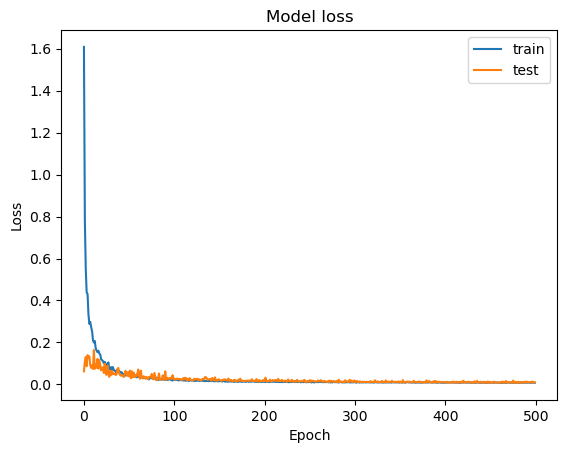

3/3 [==============================] - 0s 2ms/step
MSE: 0.01
R2: 0.78
Epoch 1/500
7/7 - 1s - loss: 1.3267 - mean_squared_error: 1.3267 - val_loss: 0.0556 - val_mean_squared_error: 0.0556 - 1s/epoch - 191ms/step
Epoch 2/500
7/7 - 0s - loss: 0.6124 - mean_squared_error: 0.6124 - val_loss: 0.0600 - val_mean_squared_error: 0.0600 - 59ms/epoch - 8ms/step
Epoch 3/500
7/7 - 0s - loss: 0.4681 - mean_squared_error: 0.4681 - val_loss: 0.0773 - val_mean_squared_error: 0.0773 - 54ms/epoch - 8ms/step
Epoch 4/500
7/7 - 0s - loss: 0.4025 - mean_squared_error: 0.4025 - val_loss: 0.0762 - val_mean_squared_error: 0.0762 - 61ms/epoch - 9ms/step
Epoch 5/500
7/7 - 0s - loss: 0.2970 - mean_squared_error: 0.2970 - val_loss: 0.1322 - val_mean_squared_error: 0.1322 - 61ms/epoch - 9ms/step
Epoch 6/500
7/7 - 0s - loss: 0.2882 - mean_squared_error: 0.2882 - val_loss: 0.0950 - val_mean_squared_error: 0.0950 - 66ms/epoch - 9ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2720 - mean_squared_error: 0.2720 - val_loss: 0.0960 

Epoch 54/500
7/7 - 0s - loss: 0.0368 - mean_squared_error: 0.0368 - val_loss: 0.0270 - val_mean_squared_error: 0.0270 - 55ms/epoch - 8ms/step
Epoch 55/500
7/7 - 0s - loss: 0.0315 - mean_squared_error: 0.0315 - val_loss: 0.0197 - val_mean_squared_error: 0.0197 - 54ms/epoch - 8ms/step
Epoch 56/500
7/7 - 0s - loss: 0.0268 - mean_squared_error: 0.0268 - val_loss: 0.0245 - val_mean_squared_error: 0.0245 - 52ms/epoch - 7ms/step
Epoch 57/500
7/7 - 0s - loss: 0.0338 - mean_squared_error: 0.0338 - val_loss: 0.0289 - val_mean_squared_error: 0.0289 - 55ms/epoch - 8ms/step
Epoch 58/500
7/7 - 0s - loss: 0.0294 - mean_squared_error: 0.0294 - val_loss: 0.0299 - val_mean_squared_error: 0.0299 - 55ms/epoch - 8ms/step
Epoch 59/500
7/7 - 0s - loss: 0.0318 - mean_squared_error: 0.0318 - val_loss: 0.0304 - val_mean_squared_error: 0.0304 - 54ms/epoch - 8ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0300 - mean_squared_error: 0.0300 - val_loss: 0.0305 - val_mean_squared_error: 0.0305 - 55ms/epoch - 8ms/step
Epoch 

Epoch 112/500
7/7 - 0s - loss: 0.0185 - mean_squared_error: 0.0185 - val_loss: 0.0194 - val_mean_squared_error: 0.0194 - 54ms/epoch - 8ms/step
Epoch 113/500
7/7 - 0s - loss: 0.0162 - mean_squared_error: 0.0162 - val_loss: 0.0237 - val_mean_squared_error: 0.0237 - 55ms/epoch - 8ms/step
Epoch 114/500
7/7 - 0s - loss: 0.0204 - mean_squared_error: 0.0204 - val_loss: 0.0252 - val_mean_squared_error: 0.0252 - 54ms/epoch - 8ms/step
Epoch 115/500
7/7 - 0s - loss: 0.0162 - mean_squared_error: 0.0162 - val_loss: 0.0264 - val_mean_squared_error: 0.0264 - 67ms/epoch - 10ms/step
Epoch 116/500
7/7 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0208 - val_mean_squared_error: 0.0208 - 54ms/epoch - 8ms/step
Epoch 117/500
7/7 - 0s - loss: 0.0197 - mean_squared_error: 0.0197 - val_loss: 0.0202 - val_mean_squared_error: 0.0202 - 52ms/epoch - 7ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0170 - mean_squared_error: 0.0170 - val_loss: 0.0239 - val_mean_squared_error: 0.0239 - 49ms/epoch - 7ms/ste

Epoch 170/500
7/7 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0203 - val_mean_squared_error: 0.0203 - 51ms/epoch - 7ms/step
Epoch 171/500
7/7 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0222 - val_mean_squared_error: 0.0222 - 50ms/epoch - 7ms/step
Epoch 172/500
7/7 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0160 - val_mean_squared_error: 0.0160 - 50ms/epoch - 7ms/step
Epoch 173/500
7/7 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0248 - val_mean_squared_error: 0.0248 - 51ms/epoch - 7ms/step
Epoch 174/500
7/7 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0174 - val_mean_squared_error: 0.0174 - 53ms/epoch - 8ms/step
Epoch 175/500
7/7 - 0s - loss: 0.0139 - mean_squared_error: 0.0139 - val_loss: 0.0201 - val_mean_squared_error: 0.0201 - 51ms/epoch - 7ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0166 - val_mean_squared_error: 0.0166 - 53ms/epoch - 8ms/step

Epoch 228/500
7/7 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0198 - val_mean_squared_error: 0.0198 - 60ms/epoch - 9ms/step
Epoch 229/500
7/7 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 61ms/epoch - 9ms/step
Epoch 230/500
7/7 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 54ms/epoch - 8ms/step
Epoch 231/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 50ms/epoch - 7ms/step
Epoch 232/500
7/7 - 0s - loss: 0.0135 - mean_squared_error: 0.0135 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 55ms/epoch - 8ms/step
Epoch 233/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 72ms/epoch - 10ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0171 - val_mean_squared_error: 0.0171 - 73ms/epoch - 10ms/st

Epoch 286/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 51ms/epoch - 7ms/step
Epoch 287/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0207 - val_mean_squared_error: 0.0207 - 49ms/epoch - 7ms/step
Epoch 288/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0113 - val_mean_squared_error: 0.0113 - 49ms/epoch - 7ms/step
Epoch 289/500
7/7 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0193 - val_mean_squared_error: 0.0193 - 49ms/epoch - 7ms/step
Epoch 290/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 56ms/epoch - 8ms/step
Epoch 291/500
7/7 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 54ms/epoch - 8ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 60ms/epoch - 9ms/step

Epoch 344/500
7/7 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 47ms/epoch - 7ms/step
Epoch 345/500
7/7 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 61ms/epoch - 9ms/step
Epoch 346/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 49ms/epoch - 7ms/step
Epoch 347/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 32ms/epoch - 5ms/step
Epoch 348/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 57ms/epoch - 8ms/step
Epoch 349/500
7/7 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 55ms/epoch - 8ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 50ms/epoch - 7ms/step

Epoch 402/500
7/7 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0097 - val_mean_squared_error: 0.0097 - 44ms/epoch - 6ms/step
Epoch 403/500
7/7 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 46ms/epoch - 7ms/step
Epoch 404/500
7/7 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 48ms/epoch - 7ms/step
Epoch 405/500
7/7 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 49ms/epoch - 7ms/step
Epoch 406/500
7/7 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 44ms/epoch - 6ms/step
Epoch 407/500
7/7 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 48ms/epoch - 7ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - 55ms/epoch - 8ms/step

Epoch 460/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 50ms/epoch - 7ms/step
Epoch 461/500
7/7 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - 49ms/epoch - 7ms/step
Epoch 462/500
7/7 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 54ms/epoch - 8ms/step
Epoch 463/500
7/7 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 54ms/epoch - 8ms/step
Epoch 464/500
7/7 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 75ms/epoch - 11ms/step
Epoch 465/500
7/7 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 60ms/epoch - 9ms/step
Epoch 466/500
7/7 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 60ms/epoch - 9ms/ste

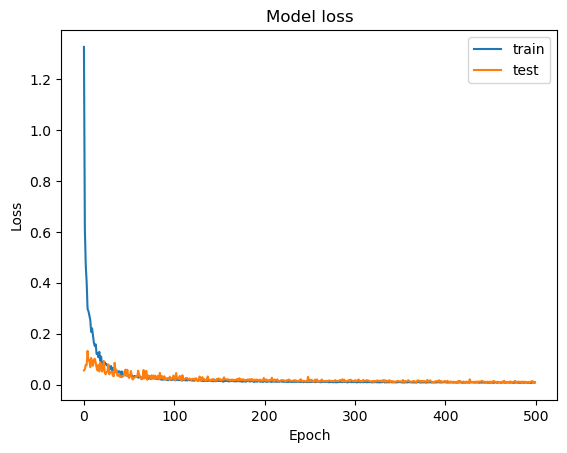

3/3 [==============================] - 0s 3ms/step
MSE: 0.01
R2: 0.78
Epoch 1/500
7/7 - 1s - loss: 1.2342 - mean_squared_error: 1.2342 - val_loss: 0.0520 - val_mean_squared_error: 0.0520 - 1s/epoch - 196ms/step
Epoch 2/500
7/7 - 0s - loss: 0.6731 - mean_squared_error: 0.6731 - val_loss: 0.0852 - val_mean_squared_error: 0.0852 - 48ms/epoch - 7ms/step
Epoch 3/500
7/7 - 0s - loss: 0.5207 - mean_squared_error: 0.5207 - val_loss: 0.1075 - val_mean_squared_error: 0.1075 - 53ms/epoch - 8ms/step
Epoch 4/500
7/7 - 0s - loss: 0.4326 - mean_squared_error: 0.4326 - val_loss: 0.0815 - val_mean_squared_error: 0.0815 - 67ms/epoch - 10ms/step
Epoch 5/500
7/7 - 0s - loss: 0.3569 - mean_squared_error: 0.3569 - val_loss: 0.1293 - val_mean_squared_error: 0.1293 - 53ms/epoch - 8ms/step
Epoch 6/500
7/7 - 0s - loss: 0.3182 - mean_squared_error: 0.3182 - val_loss: 0.2179 - val_mean_squared_error: 0.2179 - 72ms/epoch - 10ms/step
Epoch 7/500
7/7 - 0s - loss: 0.3152 - mean_squared_error: 0.3152 - val_loss: 0.057

Epoch 59/500
7/7 - 0s - loss: 0.0307 - mean_squared_error: 0.0307 - val_loss: 0.0794 - val_mean_squared_error: 0.0794 - 49ms/epoch - 7ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0355 - mean_squared_error: 0.0355 - val_loss: 0.0225 - val_mean_squared_error: 0.0225 - 47ms/epoch - 7ms/step
Epoch 61/500
7/7 - 0s - loss: 0.0256 - mean_squared_error: 0.0256 - val_loss: 0.0248 - val_mean_squared_error: 0.0248 - 64ms/epoch - 9ms/step
Epoch 62/500
7/7 - 0s - loss: 0.0250 - mean_squared_error: 0.0250 - val_loss: 0.0629 - val_mean_squared_error: 0.0629 - 50ms/epoch - 7ms/step
Epoch 63/500
7/7 - 0s - loss: 0.0301 - mean_squared_error: 0.0301 - val_loss: 0.0241 - val_mean_squared_error: 0.0241 - 49ms/epoch - 7ms/step
Epoch 64/500
7/7 - 0s - loss: 0.0315 - mean_squared_error: 0.0315 - val_loss: 0.0238 - val_mean_squared_error: 0.0238 - 45ms/epoch - 6ms/step
Epoch 65/500
7/7 - 0s - loss: 0.0310 - mean_squared_error: 0.0310 - val_loss: 0.0321 - val_mean_squared_error: 0.0321 - 64ms/epoch - 9ms/step
Epoch 

Epoch 117/500
7/7 - 0s - loss: 0.0202 - mean_squared_error: 0.0202 - val_loss: 0.0180 - val_mean_squared_error: 0.0180 - 78ms/epoch - 11ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0148 - mean_squared_error: 0.0148 - val_loss: 0.0208 - val_mean_squared_error: 0.0208 - 68ms/epoch - 10ms/step
Epoch 119/500
7/7 - 0s - loss: 0.0214 - mean_squared_error: 0.0214 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 67ms/epoch - 10ms/step
Epoch 120/500
7/7 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 59ms/epoch - 8ms/step
Epoch 121/500
7/7 - 0s - loss: 0.0213 - mean_squared_error: 0.0213 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 59ms/epoch - 8ms/step
Epoch 122/500
7/7 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0342 - val_mean_squared_error: 0.0342 - 53ms/epoch - 8ms/step
Epoch 123/500
7/7 - 0s - loss: 0.0187 - mean_squared_error: 0.0187 - val_loss: 0.0211 - val_mean_squared_error: 0.0211 - 53ms/epoch - 8ms/s

Epoch 175/500
7/7 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0193 - val_mean_squared_error: 0.0193 - 54ms/epoch - 8ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0149 - mean_squared_error: 0.0149 - val_loss: 0.0159 - val_mean_squared_error: 0.0159 - 71ms/epoch - 10ms/step
Epoch 177/500
7/7 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 52ms/epoch - 7ms/step
Epoch 178/500
7/7 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0246 - val_mean_squared_error: 0.0246 - 55ms/epoch - 8ms/step
Epoch 179/500
7/7 - 0s - loss: 0.0123 - mean_squared_error: 0.0123 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 52ms/epoch - 7ms/step
Epoch 180/500
7/7 - 0s - loss: 0.0135 - mean_squared_error: 0.0135 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 54ms/epoch - 8ms/step
Epoch 181/500
7/7 - 0s - loss: 0.0147 - mean_squared_error: 0.0147 - val_loss: 0.0261 - val_mean_squared_error: 0.0261 - 66ms/epoch - 9ms/ste

Epoch 233/500
7/7 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 78ms/epoch - 11ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0143 - mean_squared_error: 0.0143 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 73ms/epoch - 10ms/step
Epoch 235/500
7/7 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 66ms/epoch - 9ms/step
Epoch 236/500
7/7 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 67ms/epoch - 10ms/step
Epoch 237/500
7/7 - 0s - loss: 0.0144 - mean_squared_error: 0.0144 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 60ms/epoch - 9ms/step
Epoch 238/500
7/7 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 55ms/epoch - 8ms/step
Epoch 239/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0214 - val_mean_squared_error: 0.0214 - 60ms/epoch - 9ms/s

Epoch 291/500
7/7 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 75ms/epoch - 11ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 62ms/epoch - 9ms/step
Epoch 293/500
7/7 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 47ms/epoch - 7ms/step
Epoch 294/500
7/7 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 74ms/epoch - 11ms/step
Epoch 295/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 55ms/epoch - 8ms/step
Epoch 296/500
7/7 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0208 - val_mean_squared_error: 0.0208 - 72ms/epoch - 10ms/step
Epoch 297/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 66ms/epoch - 9ms/s

Epoch 349/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0103 - val_mean_squared_error: 0.0103 - 55ms/epoch - 8ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0185 - val_mean_squared_error: 0.0185 - 55ms/epoch - 8ms/step
Epoch 351/500
7/7 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 55ms/epoch - 8ms/step
Epoch 352/500
7/7 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 52ms/epoch - 7ms/step
Epoch 353/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 50ms/epoch - 7ms/step
Epoch 354/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 50ms/epoch - 7ms/step
Epoch 355/500
7/7 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 50ms/epoch - 7ms/step

Epoch 407/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 42ms/epoch - 6ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 54ms/epoch - 8ms/step
Epoch 409/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0189 - val_mean_squared_error: 0.0189 - 57ms/epoch - 8ms/step
Epoch 410/500
7/7 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 53ms/epoch - 8ms/step
Epoch 411/500
7/7 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 50ms/epoch - 7ms/step
Epoch 412/500
7/7 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0133 - val_mean_squared_error: 0.0133 - 59ms/epoch - 8ms/step
Epoch 413/500
7/7 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 52ms/epoch - 7ms/step

Epoch 465/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0166 - val_mean_squared_error: 0.0166 - 79ms/epoch - 11ms/step
Epoch 466/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 79ms/epoch - 11ms/step
Epoch 467/500
7/7 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 79ms/epoch - 11ms/step
Epoch 468/500
7/7 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 62ms/epoch - 9ms/step
Epoch 469/500
7/7 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 48ms/epoch - 7ms/step
Epoch 470/500
7/7 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 46ms/epoch - 7ms/step
Epoch 471/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 63ms/epoch - 9ms/s

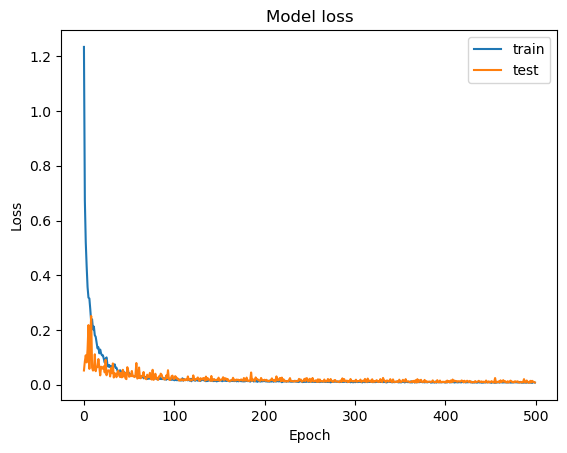

3/3 [==============================] - 0s 2ms/step
MSE: 0.01
R2: 0.80
Epoch 1/500
7/7 - 1s - loss: 1.3507 - mean_squared_error: 1.3507 - val_loss: 0.1028 - val_mean_squared_error: 0.1028 - 1s/epoch - 192ms/step
Epoch 2/500
7/7 - 0s - loss: 0.7444 - mean_squared_error: 0.7444 - val_loss: 0.2007 - val_mean_squared_error: 0.2007 - 54ms/epoch - 8ms/step
Epoch 3/500
7/7 - 0s - loss: 0.5720 - mean_squared_error: 0.5720 - val_loss: 0.1550 - val_mean_squared_error: 0.1550 - 61ms/epoch - 9ms/step
Epoch 4/500
7/7 - 0s - loss: 0.4300 - mean_squared_error: 0.4300 - val_loss: 0.1239 - val_mean_squared_error: 0.1239 - 48ms/epoch - 7ms/step
Epoch 5/500
7/7 - 0s - loss: 0.3441 - mean_squared_error: 0.3441 - val_loss: 0.1802 - val_mean_squared_error: 0.1802 - 47ms/epoch - 7ms/step
Epoch 6/500
7/7 - 0s - loss: 0.2989 - mean_squared_error: 0.2989 - val_loss: 0.2386 - val_mean_squared_error: 0.2386 - 72ms/epoch - 10ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2787 - mean_squared_error: 0.2787 - val_loss: 0.1648

Epoch 59/500
7/7 - 0s - loss: 0.0288 - mean_squared_error: 0.0288 - val_loss: 0.0269 - val_mean_squared_error: 0.0269 - 47ms/epoch - 7ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0230 - mean_squared_error: 0.0230 - val_loss: 0.0264 - val_mean_squared_error: 0.0264 - 32ms/epoch - 5ms/step
Epoch 61/500
7/7 - 0s - loss: 0.0351 - mean_squared_error: 0.0351 - val_loss: 0.0237 - val_mean_squared_error: 0.0237 - 47ms/epoch - 7ms/step
Epoch 62/500
7/7 - 0s - loss: 0.0233 - mean_squared_error: 0.0233 - val_loss: 0.0288 - val_mean_squared_error: 0.0288 - 55ms/epoch - 8ms/step
Epoch 63/500
7/7 - 0s - loss: 0.0272 - mean_squared_error: 0.0272 - val_loss: 0.0291 - val_mean_squared_error: 0.0291 - 51ms/epoch - 7ms/step
Epoch 64/500
7/7 - 0s - loss: 0.0283 - mean_squared_error: 0.0283 - val_loss: 0.0265 - val_mean_squared_error: 0.0265 - 53ms/epoch - 8ms/step
Epoch 65/500
7/7 - 0s - loss: 0.0247 - mean_squared_error: 0.0247 - val_loss: 0.0310 - val_mean_squared_error: 0.0310 - 51ms/epoch - 7ms/step
Epoch 

Epoch 117/500
7/7 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0245 - val_mean_squared_error: 0.0245 - 68ms/epoch - 10ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0200 - val_mean_squared_error: 0.0200 - 52ms/epoch - 7ms/step
Epoch 119/500
7/7 - 0s - loss: 0.0214 - mean_squared_error: 0.0214 - val_loss: 0.0203 - val_mean_squared_error: 0.0203 - 60ms/epoch - 9ms/step
Epoch 120/500
7/7 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0289 - val_mean_squared_error: 0.0289 - 54ms/epoch - 8ms/step
Epoch 121/500
7/7 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 74ms/epoch - 11ms/step
Epoch 122/500
7/7 - 0s - loss: 0.0132 - mean_squared_error: 0.0132 - val_loss: 0.0342 - val_mean_squared_error: 0.0342 - 49ms/epoch - 7ms/step
Epoch 123/500
7/7 - 0s - loss: 0.0190 - mean_squared_error: 0.0190 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 50ms/epoch - 7ms/st

Epoch 175/500
7/7 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 37ms/epoch - 5ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 47ms/epoch - 7ms/step
Epoch 177/500
7/7 - 0s - loss: 0.0176 - mean_squared_error: 0.0176 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 47ms/epoch - 7ms/step
Epoch 178/500
7/7 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0133 - val_mean_squared_error: 0.0133 - 53ms/epoch - 8ms/step
Epoch 179/500
7/7 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0271 - val_mean_squared_error: 0.0271 - 45ms/epoch - 6ms/step
Epoch 180/500
7/7 - 0s - loss: 0.0179 - mean_squared_error: 0.0179 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 44ms/epoch - 6ms/step
Epoch 181/500
7/7 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0258 - val_mean_squared_error: 0.0258 - 50ms/epoch - 7ms/step

Epoch 233/500
7/7 - 0s - loss: 0.0145 - mean_squared_error: 0.0145 - val_loss: 0.0135 - val_mean_squared_error: 0.0135 - 60ms/epoch - 9ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0118 - mean_squared_error: 0.0118 - val_loss: 0.0215 - val_mean_squared_error: 0.0215 - 50ms/epoch - 7ms/step
Epoch 235/500
7/7 - 0s - loss: 0.0137 - mean_squared_error: 0.0137 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 50ms/epoch - 7ms/step
Epoch 236/500
7/7 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0159 - val_mean_squared_error: 0.0159 - 60ms/epoch - 9ms/step
Epoch 237/500
7/7 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0159 - val_mean_squared_error: 0.0159 - 63ms/epoch - 9ms/step
Epoch 238/500
7/7 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0250 - val_mean_squared_error: 0.0250 - 47ms/epoch - 7ms/step
Epoch 239/500
7/7 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 47ms/epoch - 7ms/step

Epoch 291/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0194 - val_mean_squared_error: 0.0194 - 47ms/epoch - 7ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0135 - mean_squared_error: 0.0135 - val_loss: 0.0124 - val_mean_squared_error: 0.0124 - 61ms/epoch - 9ms/step
Epoch 293/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 48ms/epoch - 7ms/step
Epoch 294/500
7/7 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 47ms/epoch - 7ms/step
Epoch 295/500
7/7 - 0s - loss: 0.0132 - mean_squared_error: 0.0132 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 47ms/epoch - 7ms/step
Epoch 296/500
7/7 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 47ms/epoch - 7ms/step
Epoch 297/500
7/7 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 47ms/epoch - 7ms/step

Epoch 349/500
7/7 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 47ms/epoch - 7ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 47ms/epoch - 7ms/step
Epoch 351/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0087 - val_mean_squared_error: 0.0087 - 47ms/epoch - 7ms/step
Epoch 352/500
7/7 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0208 - val_mean_squared_error: 0.0208 - 53ms/epoch - 8ms/step
Epoch 353/500
7/7 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 47ms/epoch - 7ms/step
Epoch 354/500
7/7 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0219 - val_mean_squared_error: 0.0219 - 47ms/epoch - 7ms/step
Epoch 355/500
7/7 - 0s - loss: 0.0133 - mean_squared_error: 0.0133 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 47ms/epoch - 7ms/step

Epoch 407/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0149 - val_mean_squared_error: 0.0149 - 49ms/epoch - 7ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0178 - val_mean_squared_error: 0.0178 - 50ms/epoch - 7ms/step
Epoch 409/500
7/7 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 60ms/epoch - 9ms/step
Epoch 410/500
7/7 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 53ms/epoch - 8ms/step
Epoch 411/500
7/7 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 76ms/epoch - 11ms/step
Epoch 412/500
7/7 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 39ms/epoch - 6ms/step
Epoch 413/500
7/7 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 32ms/epoch - 5ms/ste

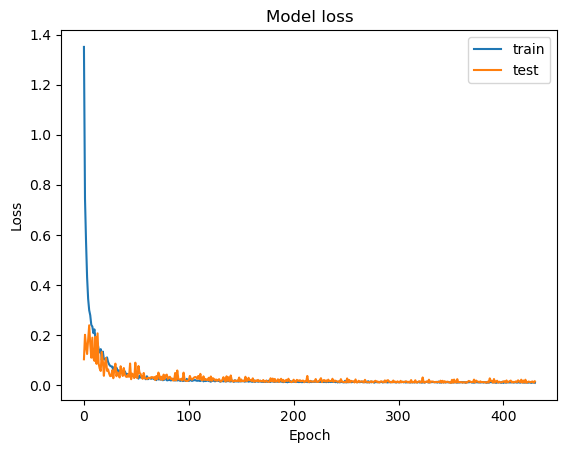

3/3 [==============================] - 0s 0s/step
MSE: 0.01
R2: 0.65
Epoch 1/500
7/7 - 1s - loss: 1.2926 - mean_squared_error: 1.2926 - val_loss: 0.8160 - val_mean_squared_error: 0.8160 - 1s/epoch - 191ms/step
Epoch 2/500
7/7 - 0s - loss: 0.6644 - mean_squared_error: 0.6644 - val_loss: 1.0636 - val_mean_squared_error: 1.0636 - 68ms/epoch - 10ms/step
Epoch 3/500
7/7 - 0s - loss: 0.5093 - mean_squared_error: 0.5093 - val_loss: 0.7497 - val_mean_squared_error: 0.7497 - 88ms/epoch - 13ms/step
Epoch 4/500
7/7 - 0s - loss: 0.3550 - mean_squared_error: 0.3550 - val_loss: 0.3635 - val_mean_squared_error: 0.3635 - 83ms/epoch - 12ms/step
Epoch 5/500
7/7 - 0s - loss: 0.3101 - mean_squared_error: 0.3101 - val_loss: 0.3018 - val_mean_squared_error: 0.3018 - 49ms/epoch - 7ms/step
Epoch 6/500
7/7 - 0s - loss: 0.2765 - mean_squared_error: 0.2765 - val_loss: 0.3751 - val_mean_squared_error: 0.3751 - 52ms/epoch - 7ms/step
Epoch 7/500
7/7 - 0s - loss: 0.2817 - mean_squared_error: 0.2817 - val_loss: 0.215

Epoch 59/500
7/7 - 0s - loss: 0.0274 - mean_squared_error: 0.0274 - val_loss: 0.0270 - val_mean_squared_error: 0.0270 - 65ms/epoch - 9ms/step
Epoch 60/500
7/7 - 0s - loss: 0.0280 - mean_squared_error: 0.0280 - val_loss: 0.0253 - val_mean_squared_error: 0.0253 - 48ms/epoch - 7ms/step
Epoch 61/500
7/7 - 0s - loss: 0.0300 - mean_squared_error: 0.0300 - val_loss: 0.0300 - val_mean_squared_error: 0.0300 - 53ms/epoch - 8ms/step
Epoch 62/500
7/7 - 0s - loss: 0.0279 - mean_squared_error: 0.0279 - val_loss: 0.0234 - val_mean_squared_error: 0.0234 - 64ms/epoch - 9ms/step
Epoch 63/500
7/7 - 0s - loss: 0.0262 - mean_squared_error: 0.0262 - val_loss: 0.0361 - val_mean_squared_error: 0.0361 - 38ms/epoch - 5ms/step
Epoch 64/500
7/7 - 0s - loss: 0.0276 - mean_squared_error: 0.0276 - val_loss: 0.0267 - val_mean_squared_error: 0.0267 - 46ms/epoch - 7ms/step
Epoch 65/500
7/7 - 0s - loss: 0.0318 - mean_squared_error: 0.0318 - val_loss: 0.0257 - val_mean_squared_error: 0.0257 - 63ms/epoch - 9ms/step
Epoch 

Epoch 117/500
7/7 - 0s - loss: 0.0177 - mean_squared_error: 0.0177 - val_loss: 0.0189 - val_mean_squared_error: 0.0189 - 51ms/epoch - 7ms/step
Epoch 118/500
7/7 - 0s - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0167 - val_mean_squared_error: 0.0167 - 43ms/epoch - 6ms/step
Epoch 119/500
7/7 - 0s - loss: 0.0178 - mean_squared_error: 0.0178 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 47ms/epoch - 7ms/step
Epoch 120/500
7/7 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0287 - val_mean_squared_error: 0.0287 - 52ms/epoch - 7ms/step
Epoch 121/500
7/7 - 0s - loss: 0.0158 - mean_squared_error: 0.0158 - val_loss: 0.0195 - val_mean_squared_error: 0.0195 - 47ms/epoch - 7ms/step
Epoch 122/500
7/7 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0225 - val_mean_squared_error: 0.0225 - 42ms/epoch - 6ms/step
Epoch 123/500
7/7 - 0s - loss: 0.0158 - mean_squared_error: 0.0158 - val_loss: 0.0205 - val_mean_squared_error: 0.0205 - 55ms/epoch - 8ms/step

Epoch 175/500
7/7 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 43ms/epoch - 6ms/step
Epoch 176/500
7/7 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 50ms/epoch - 7ms/step
Epoch 177/500
7/7 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 53ms/epoch - 8ms/step
Epoch 178/500
7/7 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0265 - val_mean_squared_error: 0.0265 - 39ms/epoch - 6ms/step
Epoch 179/500
7/7 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0241 - val_mean_squared_error: 0.0241 - 51ms/epoch - 7ms/step
Epoch 180/500
7/7 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 47ms/epoch - 7ms/step
Epoch 181/500
7/7 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0190 - val_mean_squared_error: 0.0190 - 48ms/epoch - 7ms/step

7/7 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 152ms/epoch - 22ms/step
Epoch 233/500
7/7 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0167 - val_mean_squared_error: 0.0167 - 202ms/epoch - 29ms/step
Epoch 234/500
7/7 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0135 - val_mean_squared_error: 0.0135 - 220ms/epoch - 31ms/step
Epoch 235/500
7/7 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0154 - val_mean_squared_error: 0.0154 - 155ms/epoch - 22ms/step
Epoch 236/500
7/7 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 184ms/epoch - 26ms/step
Epoch 237/500
7/7 - 0s - loss: 0.0123 - mean_squared_error: 0.0123 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 189ms/epoch - 27ms/step
Epoch 238/500
7/7 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0157 - val_mean_squared_error: 0.0157 - 134ms/epoch - 19ms/step

Epoch 290/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 49ms/epoch - 7ms/step
Epoch 291/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0217 - val_mean_squared_error: 0.0217 - 48ms/epoch - 7ms/step
Epoch 292/500
7/7 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 49ms/epoch - 7ms/step
Epoch 293/500
7/7 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 43ms/epoch - 6ms/step
Epoch 294/500
7/7 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 55ms/epoch - 8ms/step
Epoch 295/500
7/7 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 53ms/epoch - 8ms/step
Epoch 296/500
7/7 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0212 - val_mean_squared_error: 0.0212 - 49ms/epoch - 7ms/step

Epoch 348/500
7/7 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 42ms/epoch - 6ms/step
Epoch 349/500
7/7 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0102 - val_mean_squared_error: 0.0102 - 59ms/epoch - 8ms/step
Epoch 350/500
7/7 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 47ms/epoch - 7ms/step
Epoch 351/500
7/7 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 57ms/epoch - 8ms/step
Epoch 352/500
7/7 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 88ms/epoch - 13ms/step
Epoch 353/500
7/7 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 55ms/epoch - 8ms/step
Epoch 354/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 47ms/epoch - 7ms/ste

Epoch 406/500
7/7 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 47ms/epoch - 7ms/step
Epoch 407/500
7/7 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 47ms/epoch - 7ms/step
Epoch 408/500
7/7 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 48ms/epoch - 7ms/step
Epoch 409/500
7/7 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0226 - val_mean_squared_error: 0.0226 - 69ms/epoch - 10ms/step
Epoch 410/500
7/7 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 41ms/epoch - 6ms/step
Epoch 411/500
7/7 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 63ms/epoch - 9ms/step
Epoch 412/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 64ms/epoch - 9ms/ste

Epoch 464/500
7/7 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 47ms/epoch - 7ms/step
Epoch 465/500
7/7 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 47ms/epoch - 7ms/step
Epoch 466/500
7/7 - 0s - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 63ms/epoch - 9ms/step
Epoch 467/500
7/7 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 44ms/epoch - 6ms/step
Epoch 468/500
7/7 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 44ms/epoch - 6ms/step
Epoch 469/500
7/7 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 65ms/epoch - 9ms/step
Epoch 470/500
7/7 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 76ms/epoch - 11ms/ste

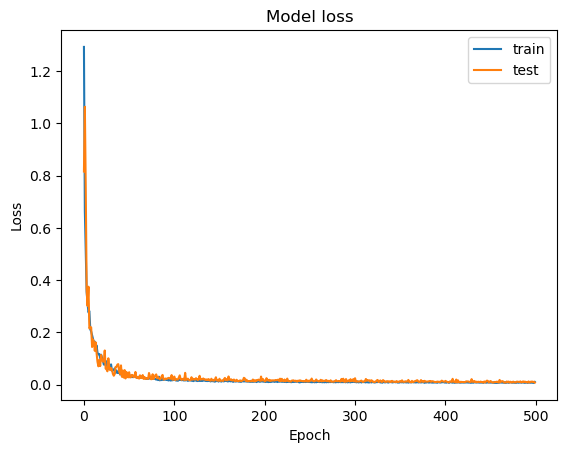

3/3 [==============================] - 0s 5ms/step
MSE: 0.01
R2: 0.80
[0.7705220555955554, 0.7896607490669628, 0.7830649049837213, 0.7506457640702936, 0.8380978141465693, 0.7750344067063293, 0.7759847205009733, 0.8010728941453884, 0.6494170749041475, 0.802362118003527]
Mean R2: 0.77 (+/- 0.05)


In [53]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from keras.layers import BatchNormalization

kfold = KFold(n_splits=10, shuffle=True, random_state=7)
cvscores = []

for train, test in kfold.split(x, y):
    # 创建模型
    model = Sequential()
    model.add(Dense(128, input_dim=input, activation='relu'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(1, activation='linear'))
    
    # 编译模型
    rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
    model.compile(loss='mean_squared_error', optimizer=rmsprop, metrics=['mean_squared_error'])
    
    # 训练模型
    early_stopping = EarlyStopping(monitor='val_loss', patience=80, verbose=2)
    history = model.fit(x, y, epochs=500, batch_size=128, shuffle=False, verbose=2,
                        validation_data=(x_test, y_test), callbacks=[early_stopping])
    
    # 绘制损失曲线
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    
    # 模型评估
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("MSE: %.2f" % mse)
    print("R2: %.2f" % r2)
    
    cvscores.append(r2)
    
print(cvscores)
print("Mean R2: %.2f (+/- %.2f)" % (np.mean(cvscores), np.std(cvscores)))

## XGBoost

In [54]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import numpy as np
import pandas as pd

In [55]:
# 定义你希望调优的参数范围
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [4, 5, 6],
    'n_estimators': [50, 100, 150],
    'gamma': [0, 0.1, 0.2],
    'alpha': [0, 0.1, 0.2],
    'lambda': [0, 0.1, 0.2]
}

# 创建XGBoost回归模型实例
xgb_reg = xgb.XGBRegressor(objective ='reg:squarederror')

# 将模型和参数范围传入 GridSearchCV，并设置交叉验证数量为 5
grid_search = GridSearchCV(xgb_reg, param_grid, cv=5, scoring='neg_mean_squared_error')

# 使用训练数据拟合 GridSearchCV
grid_search.fit(x, y)

# 打印最佳参数组合
print(f"Best parameters: {grid_search.best_params_}")

# 使用最优参数在所有训练数据上重新训练模型
best_xgb_reg = grid_search.best_estimator_

# 如果使用xgb.train，则需使用以下代码
dtrain = xgb.DMatrix(x, label=y)
dtest = xgb.DMatrix(x_test, label=y_test)

# 设置参数（使用上面GridSearchCV得到的最优参数）
best_params = grid_search.best_params_
best_params["objective"] = "reg:squarederror"

bst = xgb.train(best_params,
                dtrain,
                num_boost_round=100,
                evals=[(dtest, "test")],
                early_stopping_rounds=10,
                verbose_eval=False)

# 对测试集进行预测
preds = best_xgb_reg.predict(x_test)

# 计算并打印均方误差和确定系数（R-squared）
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE: %f" % (rmse))
print("R2: %f" % (r2))

Best parameters: {'alpha': 0.1, 'gamma': 0, 'lambda': 0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
RMSE: 0.048075
R2: 0.944622


C:\Users\zangd\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:160: UserWarning: [20:03:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


## MLP

In [56]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import numpy as np

In [57]:
# 创建多层感知机回归模型实例
mlp_regressor = MLPRegressor(random_state=42, max_iter=1000)

# 定义参数网格
param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (10,10)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01]
}

# 定义评分函数
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# 使用 GridSearchCV 进行参数优化
grid_search = GridSearchCV(mlp_regressor, param_grid, scoring=mse_scorer, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(x, y)

# 打印找到的最佳参数
print(f"Best parameters found: {grid_search.best_params_}")

# 使用最佳参数重新训练模型
best_mlp = grid_search.best_estimator_

# 模型预测
y_pred = best_mlp.predict(x_test)

# 评估模型
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'The rmse of prediction is: {rmse}')
print(f'The R^2 score of prediction is: {r2}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (10, 10), 'solver': 'lbfgs'}
The rmse of prediction is: 0.08472663354854904
The R^2 score of prediction is: 0.8279951179534252


## GBDT

In [58]:
import os
import time
from bayes_opt import BayesianOptimization
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import explained_variance_score
import matplotlib.pyplot as plt
import datetime
import pandas as pd

#t = time.localtime()
model_name = 'TRGAN200+ALL_BO_GBDT'
file_name = '{}.xlsx'.format(model_name)
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200+所有真实数据train.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200+所有真实数据test.xlsx')
train_features = train_data.drop(columns=['Time to Rupture(h)'])
train_labels = train_data[['Time to Rupture(h)']]
test_features = test_data.drop(columns=['Time to Rupture(h)'])
test_labels = test_data[['Time to Rupture(h)']]
train_features = train_features.to_numpy()
train_labels = train_labels.to_numpy()
test_features = test_features.to_numpy()
test_labels = test_labels.to_numpy()
train_labels = train_labels.reshape(-1)
test_labels = test_labels.reshape(-1)
def train_model(num_leaves,
                min_child_samples,
            learning_rate,
            n_estimators, 
            max_bin,
            colsample_bytree, 
            subsample, 
            max_depth, 
            reg_alpha,
            reg_lambda,
            min_split_gain,
            min_child_weight
            ):
    params = {
        "num_leaves": int(round(num_leaves)),
        'min_child_samples':int(round(min_child_samples)),
        'learning_rate': learning_rate,
        'n_estimators': int(round(n_estimators)),
        'max_bin': int(round(max_bin)),
        'colsample_bytree': max(min(colsample_bytree, 1), 0),
        'subsample': max(min(subsample, 1), 0),
        'max_depth': int(round(max_depth)),
        'reg_alpha':  max(reg_alpha, 0),
        'reg_lambda': max(reg_lambda, 0),
        'min_split_gain': min_split_gain,
        'min_child_weight': min_child_weight,
        'verbose': -1
                  } #the parameters you want to optimize
    model = LGBMRegressor(metric='mape',**params)
    model.fit(train_features, train_labels)
    y_pred = model.predict(test_features)
    error = -np.mean(np.abs((test_labels - y_pred) / test_labels))       # print(error)     
    return error
bounds = {'num_leaves': (5, 60),#50
          'min_child_samples':(1, 50),
          'learning_rate': (0.001, 1),
          'n_estimators': (5, 200),#100
            'max_bin': (5, 100),#10
          'colsample_bytree': (0.5, 1),
          'subsample': (0.1, 2),
          'max_depth': (1, 60),#10
          'reg_alpha': (0.01, 1), #5
          'reg_lambda': (0.01, 1),#5
          'min_split_gain': (0.001, 0.1),
          'min_child_weight': (0.0001, 30)}
optimizer = BayesianOptimization(
    f=train_model,
    pbounds=bounds,
    random_state=1,
)
optimizer.maximize(init_points = 50, n_iter=50) #here you set how many iterations you want.
table = pd.DataFrame(columns=['target', 'colsample_bytree', 'learning_rate', 'max_bin',
                      'max_depth','min_child_samples','min_child_weight','min_split_gain',
                      'n_estimators','num_leaves','reg_alpha','reg_lambda','subsample'])
for res in optimizer.res:
    table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
                                     'colsample_bytree':[res['params']['colsample_bytree']],
                                     'learning_rate':[res['params']['learning_rate']],
                                     'max_bin':[res['params']['max_bin']],
                                     'max_depth':[res['params']['max_depth']],
                                     'min_child_samples':[res['params']['min_child_samples']],
                                     'min_child_weight':[res['params']['min_child_weight']],
                                     'min_split_gain':[res['params']['min_split_gain']],
                                     'n_estimators':[res['params']['n_estimators']],
                                     'num_leaves':[res['params']['num_leaves']],
                                     'reg_alpha':[res['params']['reg_alpha']],
                                     'reg_lambda':[res['params']['reg_lambda']],
                                     'subsample':[res['params']['subsample']]}),
                                     ignore_index=True)
table=table.sort_values(by = ['target'],ascending=False)#sort the list start from the best results
table.to_excel(file_name)#save the results to the table
#endtime = datetime.datetime.now()
#print ('running time {}'.format(endtime - starttime))

|   iter    |  target   | colsam... | learni... |  max_bin  | max_depth | min_ch... | min_ch... | min_sp... | n_esti... | num_le... | reg_alpha | reg_la... | subsample |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | -16.2     | 0.7085    | 0.7206    | 5.011     | 18.84     | 8.191     | 2.77      | 0.01944   | 72.38     | 26.82     | 0.5434    | 0.425     | 1.402     |
| 2         | -18.0     | 0.6022    | 0.8782    | 7.602     | 40.56     | 21.45     | 16.76     | 0.0149    | 43.63     | 49.04     | 0.9686    | 0.3203    | 1.415     |
| 3         | -15.08    | 0.9382    | 0.8947    | 13.08     | 3.304     | 9.322     | 26.34     | 0.01074   | 87.12     | 57.68     | 0.5378    | 0.695     | 0.6995    |
| 4         | -20.87    | 0.8433    | 0.8348    | 6.737     | 45.26     | 49.45     | 22.44     | 0.02876   | 158.9     | 10.68     | 0.4534    | 0.90

| 31        | -15.69    | 0.6501    | 0.1439    | 90.62     | 32.95     | 48.76     | 19.1      | 0.0994    | 111.5     | 33.95     | 0.1441    | 0.3621    | 0.1498    |
| 32        | -18.03    | 0.5802    | 0.7459    | 7.888     | 22.63     | 43.25     | 20.78     | 0.0694    | 41.78     | 29.3      | 0.5858    | 0.9899    | 0.4874    |
| 33        | -8.515    | 0.6239    | 0.2629    | 76.27     | 27.96     | 3.79      | 15.26     | 0.02198   | 160.7     | 21.35     | 0.03733   | 0.5975    | 1.703     |
| 34        | -11.71    | 0.6905    | 0.7501    | 53.56     | 32.92     | 48.01     | 24.12     | 0.0042    | 143.3     | 30.58     | 0.9481    | 0.2292    | 0.6074    |
| 35        | -13.01    | 0.5407    | 0.4292    | 15.36     | 38.39     | 40.35     | 20.9      | 0.07685   | 71.78     | 51.52     | 0.4345    | 0.8258    | 1.29      |
| 36        | -14.86    | 0.5717    | 0.07931   | 6.742     | 4.937     | 23.47     | 3.4       | 0.003751  | 152.2     | 26.72     | 0.7495    | 0.45

| 62        | -13.54    | 0.6602    | 0.0597    | 22.55     | 50.86     | 7.509     | 14.48     | 0.03301   | 108.2     | 15.7      | 0.3227    | 0.2155    | 1.924     |
| 63        | -20.01    | 0.7131    | 0.9109    | 26.19     | 2.244     | 19.68     | 8.514     | 0.03674   | 171.6     | 5.907     | 0.1435    | 0.527     | 1.597     |
| 64        | -18.09    | 0.9738    | 0.7554    | 37.11     | 2.297     | 12.07     | 26.1      | 0.0631    | 32.85     | 39.56     | 0.5124    | 0.9101    | 1.831     |
| 65        | -12.13    | 0.8155    | 0.3256    | 75.79     | 3.615     | 11.98     | 26.37     | 0.04041   | 132.2     | 36.83     | 0.2928    | 0.3424    | 0.3438    |
| 66        | -8.542    | 0.6207    | 0.3156    | 80.5      | 33.31     | 5.505     | 15.26     | 0.03056   | 161.9     | 19.69     | 0.01683   | 0.4888    | 1.559     |
| 67        | -11.36    | 0.7191    | 0.7061    | 62.84     | 16.47     | 34.71     | 16.22     | 0.0218    | 79.54     | 40.39     | 0.7291    | 0.34

| 92        | -13.87    | 0.5094    | 0.8077    | 77.95     | 4.206     | 15.33     | 26.39     | 0.008863  | 130.0     | 36.28     | 0.9524    | 0.4748    | 1.045     |
| 93        | -11.25    | 0.6919    | 0.5448    | 81.04     | 9.142     | 34.83     | 12.92     | 0.04574   | 67.93     | 6.534     | 0.4035    | 0.6015    | 0.1626    |
| 94        | -16.8     | 0.9517    | 0.5272    | 91.25     | 55.57     | 2.771     | 8.121     | 0.0608    | 189.6     | 57.27     | 0.5822    | 0.7232    | 1.174     |
| 95        | -18.57    | 0.7744    | 0.7315    | 37.3      | 39.78     | 36.11     | 0.2378    | 0.0767    | 78.95     | 14.67     | 0.9746    | 0.9356    | 1.254     |
| 96        | -23.5     | 0.6092    | 0.4812    | 13.17     | 2.655     | 42.29     | 20.9      | 0.0411    | 64.69     | 49.29     | 0.06004   | 0.9348    | 1.348     |
| 97        | -18.35    | 0.6755    | 0.6394    | 55.2      | 19.08     | 36.48     | 8.054     | 0.00547   | 49.68     | 5.231     | 0.5808    | 0.38

C:\Users\zangd\AppData\Local\Temp\ipykernel_121208\2892934493.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_121208\2892934493.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_121208\2892934493.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_12

[1] training's mape: 0.107971 valid_0's mape: 0.128740
[2] training's mape: 0.096514 valid_0's mape: 0.121431
[3] training's mape: 0.086960 valid_0's mape: 0.115053
[4] training's mape: 0.080717 valid_0's mape: 0.110753
[5] training's mape: 0.074655 valid_0's mape: 0.107424
[6] training's mape: 0.070828 valid_0's mape: 0.103203
[7] training's mape: 0.067711 valid_0's mape: 0.097201
[8] training's mape: 0.064080 valid_0's mape: 0.094081
[9] training's mape: 0.061100 valid_0's mape: 0.091365
[10] training's mape: 0.059141 valid_0's mape: 0.090245
[11] training's mape: 0.058202 valid_0's mape: 0.090307
[12] training's mape: 0.056908 valid_0's mape: 0.089176
[13] training's mape: 0.056573 valid_0's mape: 0.088674
[14] training's mape: 0.055682 valid_0's mape: 0.087943
[15] training's mape: 0.054516 valid_0's mape: 0.086065
[16] training's mape: 0.054379 valid_0's mape: 0.086034
[17] training's mape: 0.054350 valid_0's mape: 0.085880
[18] training's mape: 0.054350 valid_0's mape: 0.085880
[

NameError: name 'torch' is not defined

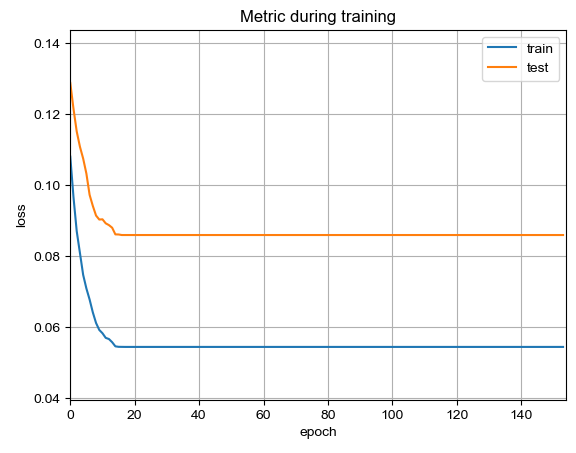

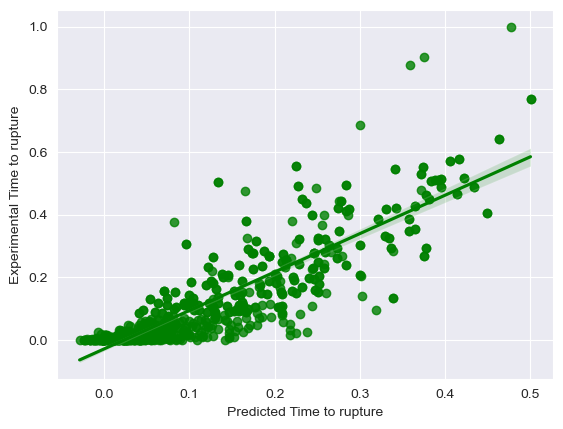

In [59]:
import lightgbm as lgb
import seaborn as sns
#load the parameters of BO
target = pd.read_excel('TRGAN200+ALL_BO_GBDT.xlsx')
colsample_bytree = target.at[1,'colsample_bytree']
learning_rate = target.at[1,'learning_rate']
max_bin = target.at[1,'max_bin']
max_depth = target.at[1,'max_depth']
max_bin = target.at[1,'max_bin']
min_child_samples = target.at[1,'min_child_samples']
min_child_weight = target.at[1,'min_child_weight']
min_split_gain= target.at[1,'min_split_gain']
n_estimators = target.at[1,'n_estimators']
num_leaves = target.at[1,'num_leaves']
reg_alpha = target.at[1,'reg_alpha']
reg_lambda = target.at[1,'reg_lambda']
subsample = target.at[1,'subsample']
params = {
    "num_leaves": int(round(num_leaves)),
    'min_child_samples':int(round(min_child_samples)),
    'learning_rate': learning_rate,
    'n_estimators': int(round(n_estimators)),
    'max_bin': int(round(max_bin)),
    'colsample_bytree': max(min(colsample_bytree, 1), 0),
    'subsample': max(min(subsample, 1), 0),
    'max_depth': int(round(max_depth)),
    'reg_lambda':  max(reg_lambda, 0),
    'reg_alpha': max(reg_alpha, 0),
    'min_split_gain': min_split_gain,
    'min_child_weight': min_child_weight,
    'objective': 'regression',
    'verbose': -1
              }
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200+所有真实数据train.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200+所有真实数据test.xlsx')
train_features = train_data.drop(columns=['Time to Rupture(h)'])
train_labels = train_data[['Time to Rupture(h)']]
test_features = test_data.drop(columns=['Time to Rupture(h)'])
test_labels = test_data[['Time to Rupture(h)']]
train_features = train_features.to_numpy()
train_labels = train_labels.to_numpy()
test_features = test_features.to_numpy()
test_labels = test_labels.to_numpy()
train_labels = train_labels.reshape(-1)
test_labels = test_labels.reshape(-1) 

model = LGBMRegressor(metric='mape', **params)
model.fit(train_features, train_labels, eval_set=[(test_features, test_labels), (train_features, train_labels)],
          eval_metric='mape')

evals_result = model.evals_result_
train_mape = evals_result['training']['mape']
valid_mape = evals_result['valid_0']['mape']

for epoch, (train_mape_value, valid_mape_value) in enumerate(zip(train_mape, valid_mape), start=1):
    print(f"[{epoch}] training's mape: {train_mape_value:.6f} valid_0's mape: {valid_mape_value:.6f}")
#plot the traiining history
lgb.plot_metric(model)
plt.ylabel('loss')
plt.xlabel ('epoch')
plt.legend(['train','test'])
folder_dir = 'Figures'
if not os.path.isdir(folder_dir):
  os.mkdir(folder_dir)
plt.savefig('Figures/GBDT_trainning history.png', format='png', dpi=300)
#plotting experimental results as a change of predicted TEC 
plt.figure()
predict = model.predict(train_features)
sns.set_style("darkgrid")
sns.regplot(x=predict, y=train_labels, color='g') 
plt.xlabel ('Predicted Time to rupture')
plt.ylabel('Experimental Time to rupture')
plt.savefig('Figures/GBDT_expriements and predict comparasion.png', format='png', dpi=300)
#save the models
folder_dir = 'Model'
if not os.path.isdir(folder_dir):
  os.mkdir(folder_dir)
net_name = 'Model/TRGAN200+ALL_GBDT.pt'
torch.save(net.state_dict(), net_name)


## PSO optimization for XGBoost

In [60]:
from pyswarm import pso
from sklearn.metrics import mean_squared_error

In [61]:
train_data=pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200+所有真实数据train.xlsx')
test_data=pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200+所有真实数据test.xlsx')
x_train = train_data.drop(columns=[ 'Time to Rupture(h)'])
y_train = train_data['Time to Rupture(h)']
x_test = test_data.drop(columns=['Time to Rupture(h)'])
y_test = test_data['Time to Rupture(h)']

In [62]:
def objective_func(particle_position):
    max_depth = int(particle_position[0])
    learning_rate = particle_position[1]
    n_estimators = int(particle_position[2])
    min_child_weight = int(particle_position[3])
    subsample = particle_position[4]
    gamma = particle_position[5]

    model = xgb.XGBRegressor(max_depth=max_depth,
                             learning_rate=learning_rate,
                             n_estimators=n_estimators,
                             min_child_weight=min_child_weight,
                             subsample=subsample,
                             gamma=gamma)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [63]:
lb = [1, 0.001, 50, 1, 0.1, 0]
ub = [10, 0.5, 500, 10, 1, 1]

xopt, fopt = pso(objective_func, lb, ub, swarmsize=30, maxiter=100)
print('Found optimal solution: ', xopt)
print('Objective function at optimal solution: ', fopt)

Stopping search: Swarm best objective change less than 1e-08
Found optimal solution:  [  7.15858504   0.36450891 346.96963853   2.62608928   0.40628199
   0.        ]
Objective function at optimal solution:  0.0009080403059673297


In [64]:
max_depth = int(xopt[0])
learning_rate = xopt[1]
n_estimators = int(xopt[2])
min_child_weight = int(xopt[3])
subsample = xopt[4]
gamma = xopt[5]

model_optimal = xgb.XGBRegressor(max_depth=max_depth,
                                 learning_rate=learning_rate,
                                 n_estimators=n_estimators,
                                 min_child_weight=min_child_weight,
                                 subsample=subsample,
                                 gamma=gamma)
model_optimal.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.36450891068016095,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=2, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=346, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [66]:
from sklearn.metrics import mean_absolute_error, r2_score

# 预测 x_test
y_pred = model_optimal.predict(x_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Mean Absolute Error (MAE): {mae:.5f}")
print(f"R2 Score: {r2:.5f}")

Mean Squared Error (MSE): 0.00091
Mean Absolute Error (MAE): 0.01628
R2 Score: 0.97824


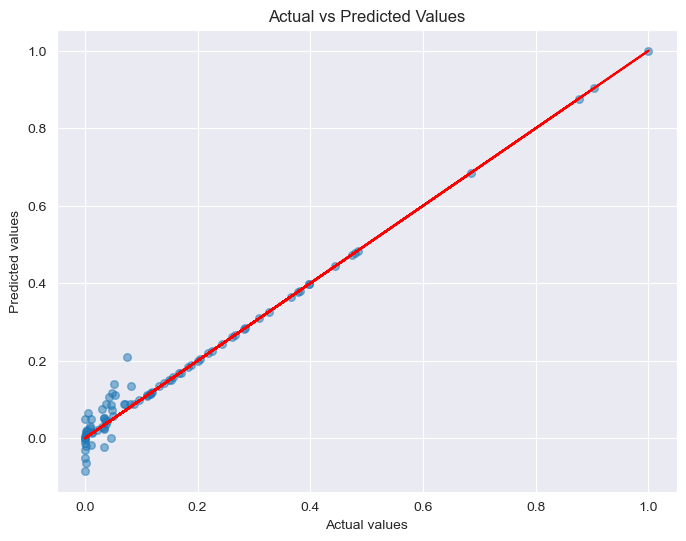

In [67]:
import matplotlib.pyplot as plt

# Draw scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, s=30, alpha=0.5)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')

# Draw line for perfect predictions
plt.plot(y_test, y_test, 'r')

plt.show()

## PSO optimization for GBDT

In [68]:
from sklearn.ensemble import GradientBoostingRegressor

def objective_func(particle_position):
    max_depth = int(particle_position[0])
    learning_rate = particle_position[1]
    n_estimators = int(particle_position[2])
    min_samples_split = int(particle_position[3])
    subsample = particle_position[4]

    model = GradientBoostingRegressor(max_depth=max_depth,
                                      learning_rate=learning_rate,
                                      n_estimators=n_estimators,
                                      min_samples_split=min_samples_split,
                                      subsample=subsample)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [69]:
lb = [1, 0.001, 50, 2, 0.1]
ub = [10, 0.5, 500, 5, 1]

xopt, fopt = pso(objective_func, lb, ub, swarmsize=30, maxiter=100)
print('Found optimal solution: ', xopt)
print('Objective function at optimal solution: ', fopt)

Stopping search: maximum iterations reached --> 100
Found optimal solution:  [  9.00602619   0.29915871 240.33066808   3.29246455   0.7582703 ]
Objective function at optimal solution:  0.0006217900329237537


In [70]:
max_depth = int(xopt[0])
learning_rate = xopt[1]
n_estimators = int(xopt[2])
min_samples_split = int(xopt[3])
subsample = xopt[4]

model_optimal = GradientBoostingRegressor(max_depth=max_depth,
                                          learning_rate=learning_rate,
                                          n_estimators=n_estimators,
                                          min_samples_split=min_samples_split,
                                          subsample=subsample)

model_optimal.fit(x_train, y_train)

GradientBoostingRegressor(learning_rate=0.2991587073811578, max_depth=9,
                          min_samples_split=3, n_estimators=240,
                          subsample=0.758270302666289)

In [71]:
# 预测 x_test
y_pred = model_optimal.predict(x_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error (MSE): 0.00
Mean Absolute Error (MAE): 0.02
R2 Score: 0.96


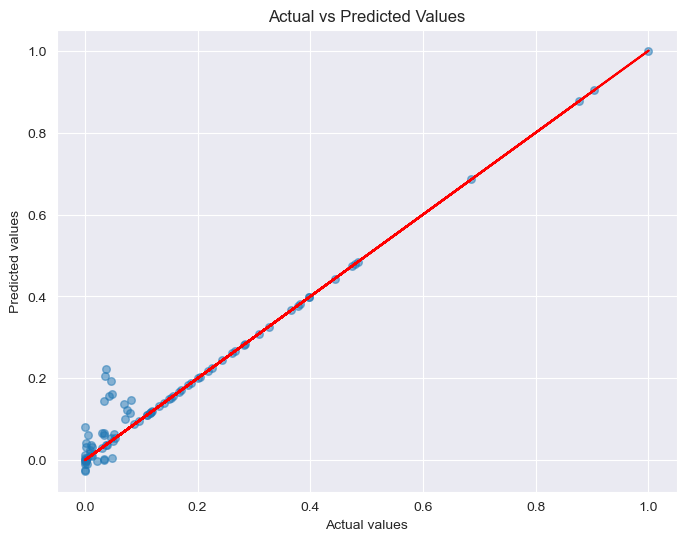

In [72]:
# Draw scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, s=30, alpha=0.5)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')

# Draw line for perfect predictions
plt.plot(y_test, y_test, 'r')

plt.show()